# ✈️ NASA C-MAPSS FD001 — EDA + 전처리 파이프라인 (결정 1~4)

---
**목적:** 전처리 전 EDA → 결정 1~4 적용 → 전처리 후 검증 → CSV 저장  
**대상:** FD001 (단일 운전 조건, HPC 열화만)  
**출력:** `preprocessed/FD001_train_preprocessed.csv` / `FD001_test_preprocessed.csv` / `FD001_test_RUL.csv`

---
### 노트북 흐름
```
[0] 환경 설정
[1] 데이터 로딩 & 컬럼명 표준화
[2] 전처리 전 EDA
     ├─ 2-1. 기초 통계 & 데이터 품질
     ├─ 2-2. 엔진 수명 분포
     ├─ 2-3. 센서 분포 & 이상치
     ├─ 2-4. 센서 간 상관관계 히트맵
     ├─ 2-5. 센서별 열화 트렌드
     ├─ 2-6. ADF 정상성 검정
     └─ 2-7. RUL 상관계수
[3] 결정 1 — 상수 센서 제거 (21→14)
[4] 결정 2 — Piecewise RUL (Cap=125)
[5] 결정 3 — MinMax 정규화
[6] 결정 4 — Gaussian 스무딩 (σ=2)
[7] 전처리 후 검증 (전후 비교)
     ├─ 7-1. 상관관계 전후 비교
     ├─ 7-2. ADF 검정 전후 비교
     ├─ 7-3. 센서 분포 전후 비교
     ├─ 7-4. Train vs Test 분포 비교
     └─ 7-5. 열화 트렌드 전후 비교
[8] CSV 저장 & 최종 요약
```

## 0. 환경 설정

In [ ]:
import sys, subprocess
for pkg in ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn','statsmodels']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('✅ 라이브러리 설치 완료')

✅ 라이브러리 설치 완료


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ──────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ──────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')

✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01


## 1. 데이터 로딩 & 컬럼명 표준화

In [3]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData','./CMAPSSData','../CMAPSSData']:
    if os.path.exists(os.path.join(c,'train_FD001.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ 경로 없음. 현재: {os.getcwd()}')  

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD001.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD001 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD001 로딩 완료
   Train : (20631, 26)  |  엔진 100대
   Test  : (13096, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [4]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

# 결측치·중복·음수 확인
quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

# 센서별 기술통계
print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,20631,0,0,0,100,✅ 정상
Test,13096,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.6809,0.5001,641.2100,644.5300,0.0008
s_3,1590.5231,6.1311,1571.0400,1616.9100,0.0039
s_4,1408.9338,9.0006,1382.2500,1441.4900,0.0064
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.6098,0.0014,21.6000,21.6100,0.0001
s_7,553.3677,0.8851,549.8500,556.0600,0.0016
s_8,2388.0967,0.0710,2387.9000,2388.5600,0.0000
s_9,9065.2429,22.0829,9021.7300,9244.5900,0.0024
s_10,1.3000,0.0000,1.3000,1.3000,0.0000



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상


### 2-2. 엔진 수명 분포

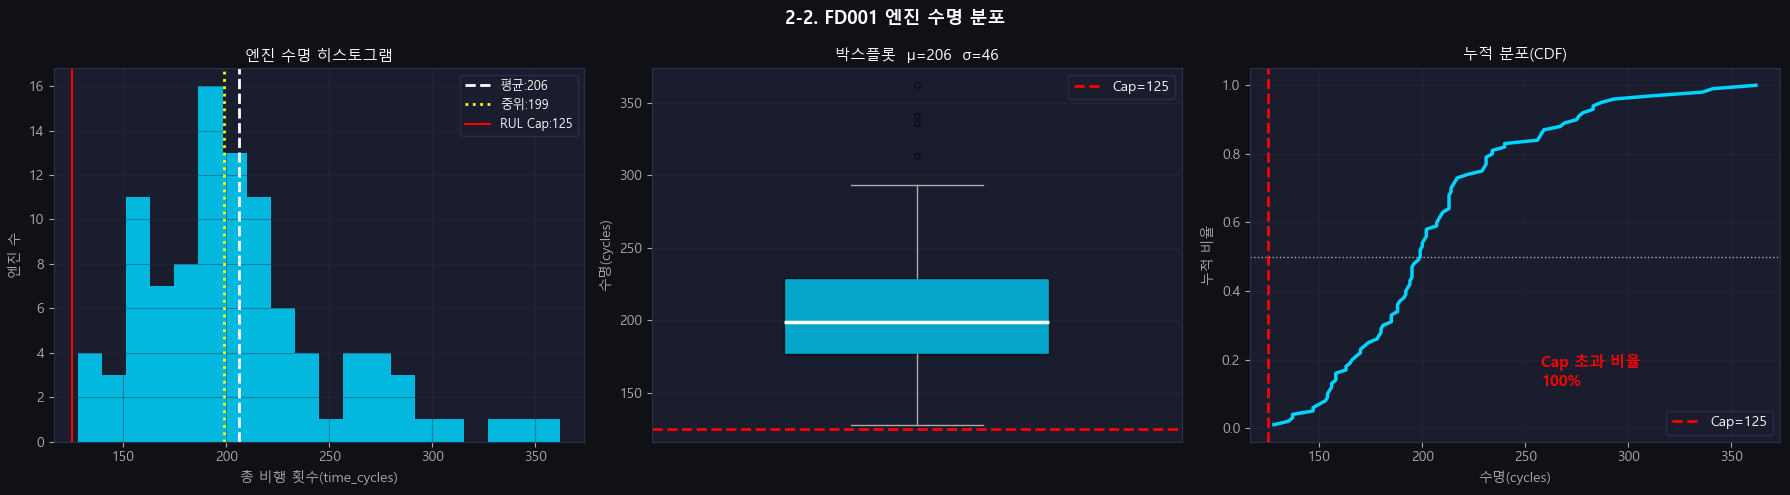


엔진 수명 통계:
  평균=206.3  중위=199.0  min=128  max=362
  Cap=125 초과 엔진: 100대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [5]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD001 엔진 수명 분포', fontsize=13, fontweight='bold')

# 히스토그램
ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)')
ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([])
ax.legend()

# CDF
ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')

### 2-3. 센서 분포 & 이상치 (전처리 전)

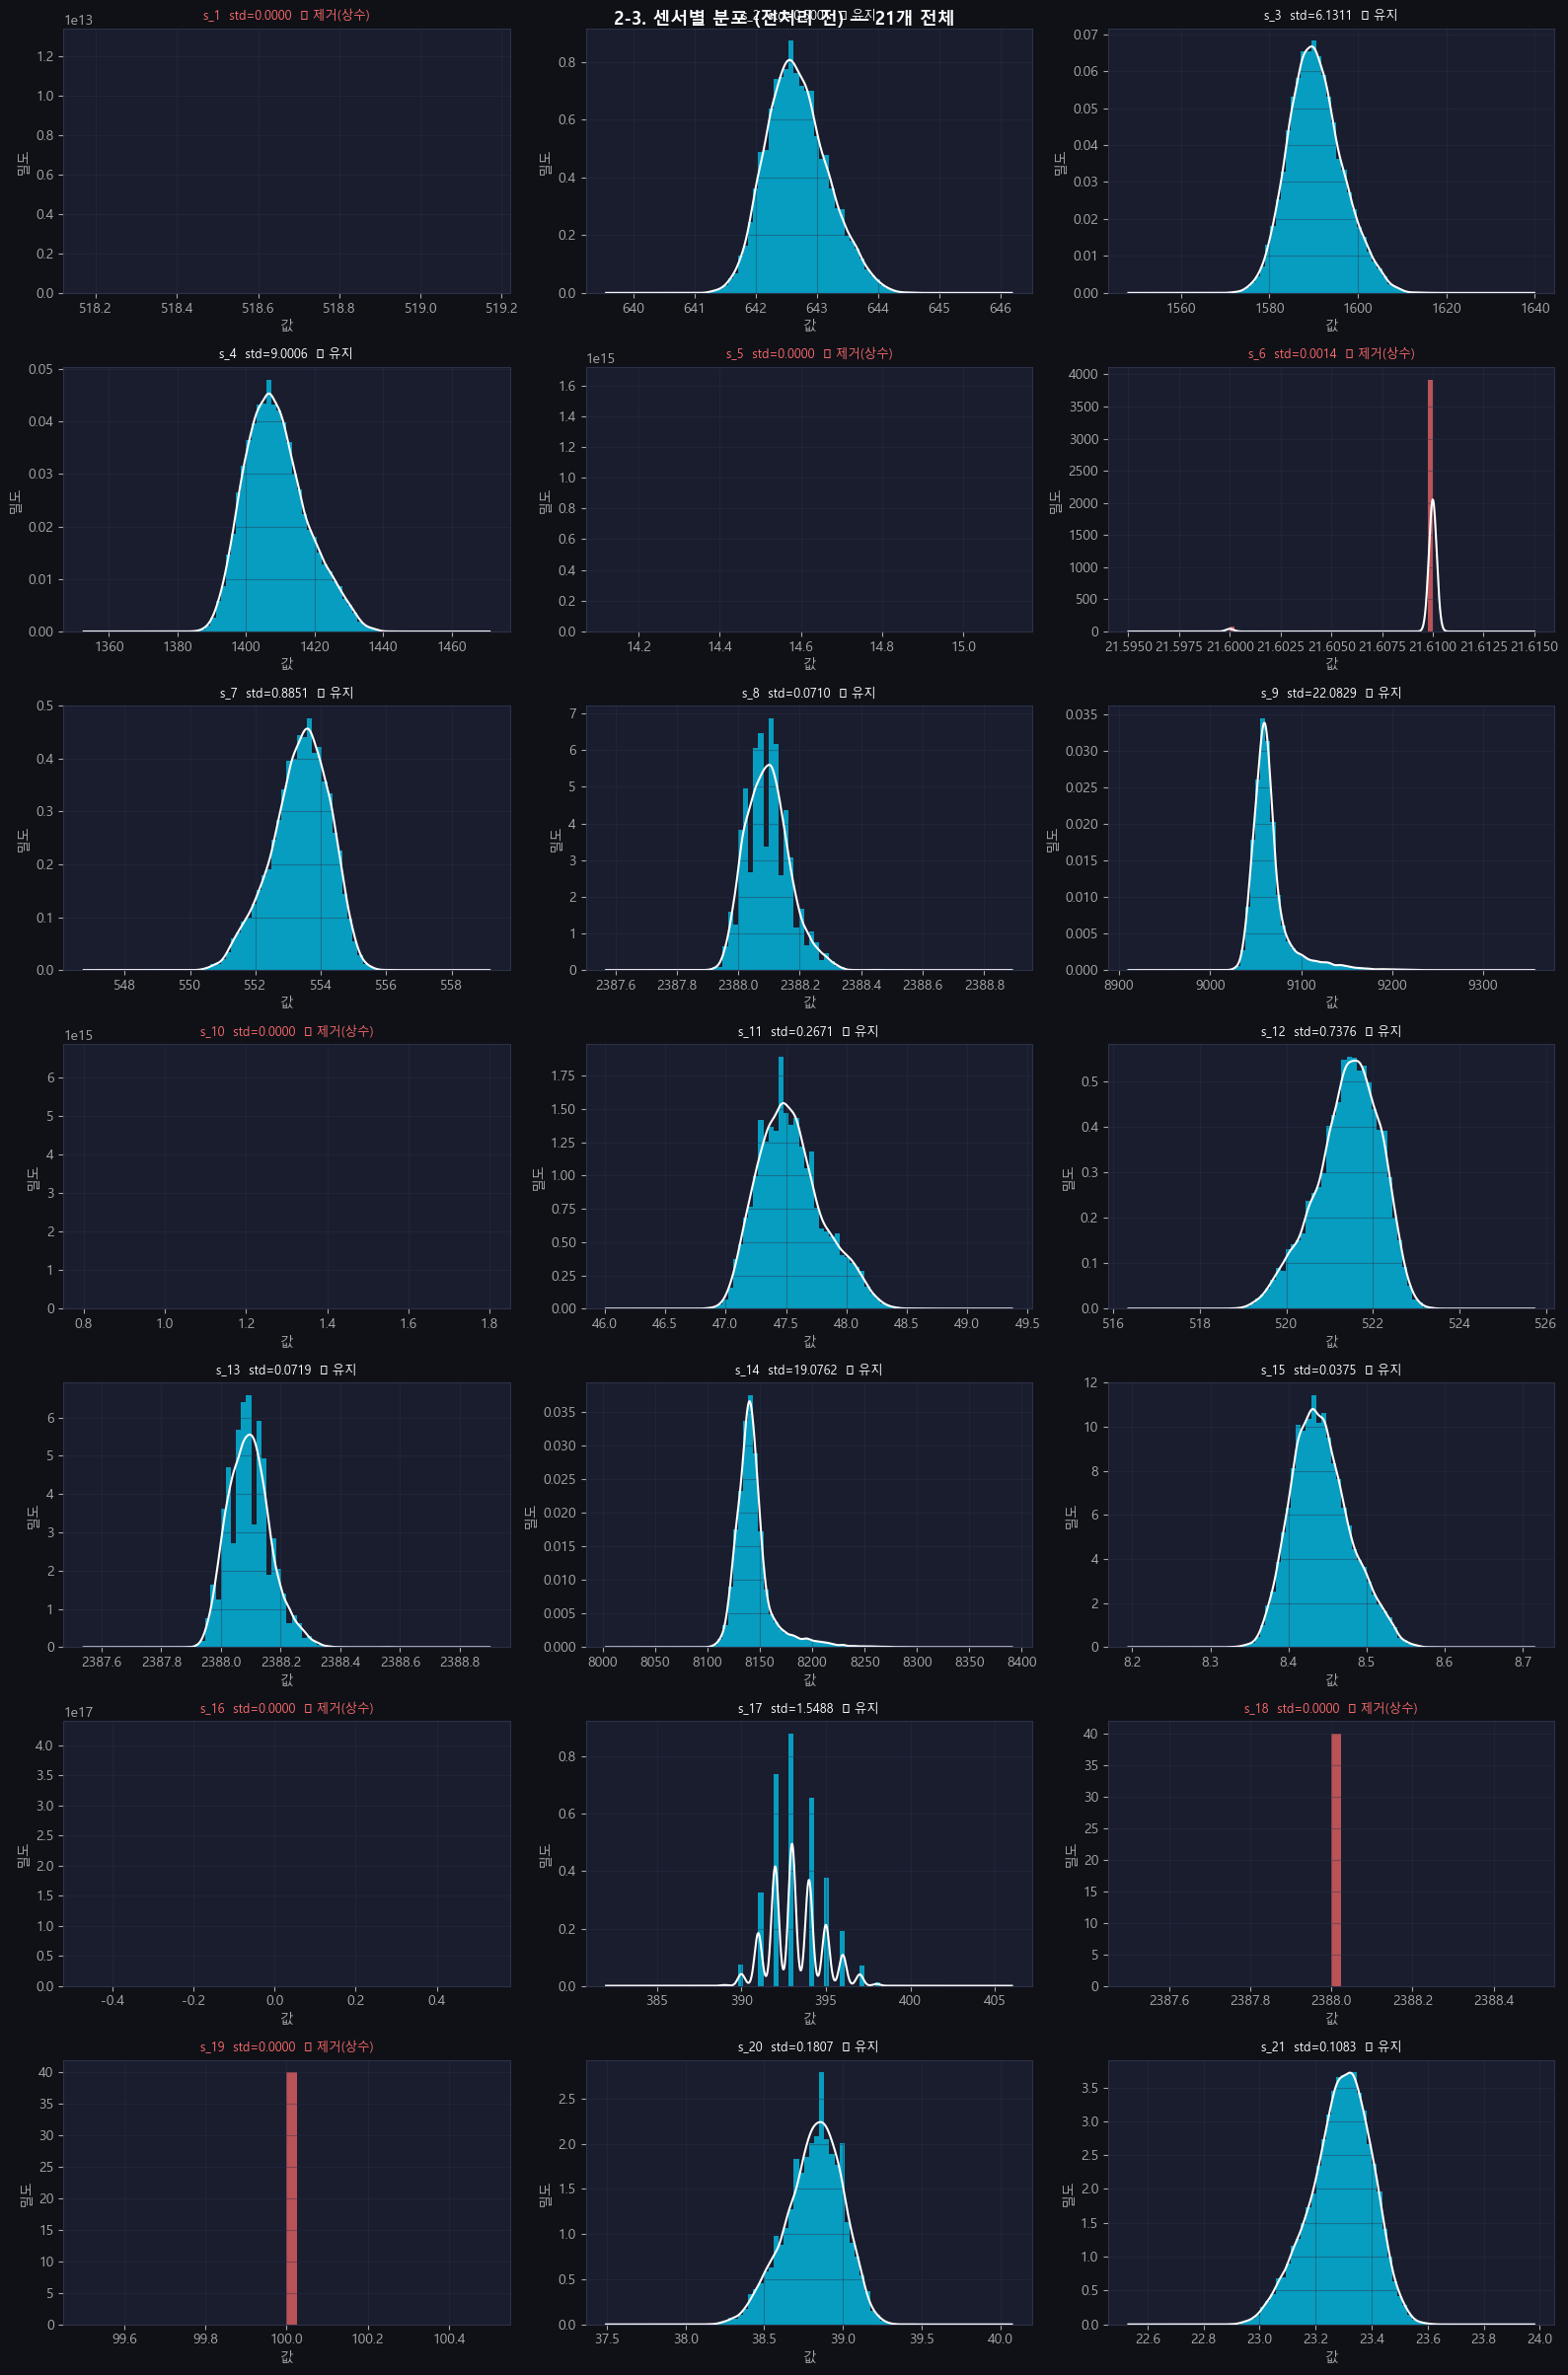

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,128,0.620
2,s_3,165,0.800
3,s_4,120,0.582
5,s_6,406,1.968
6,s_7,110,0.533
7,s_8,320,1.551
8,s_9,1686,8.172
10,s_11,167,0.809
11,s_12,146,0.708
12,s_13,161,0.780


In [6]:
# 21개 센서 분포 (히스토그램 + KDE)
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try:
        data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# IQR 이상치 탐지
print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero):
    display(nonzero)
else:
    print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 2-4. 센서 간 상관관계 히트맵 (전처리 전)

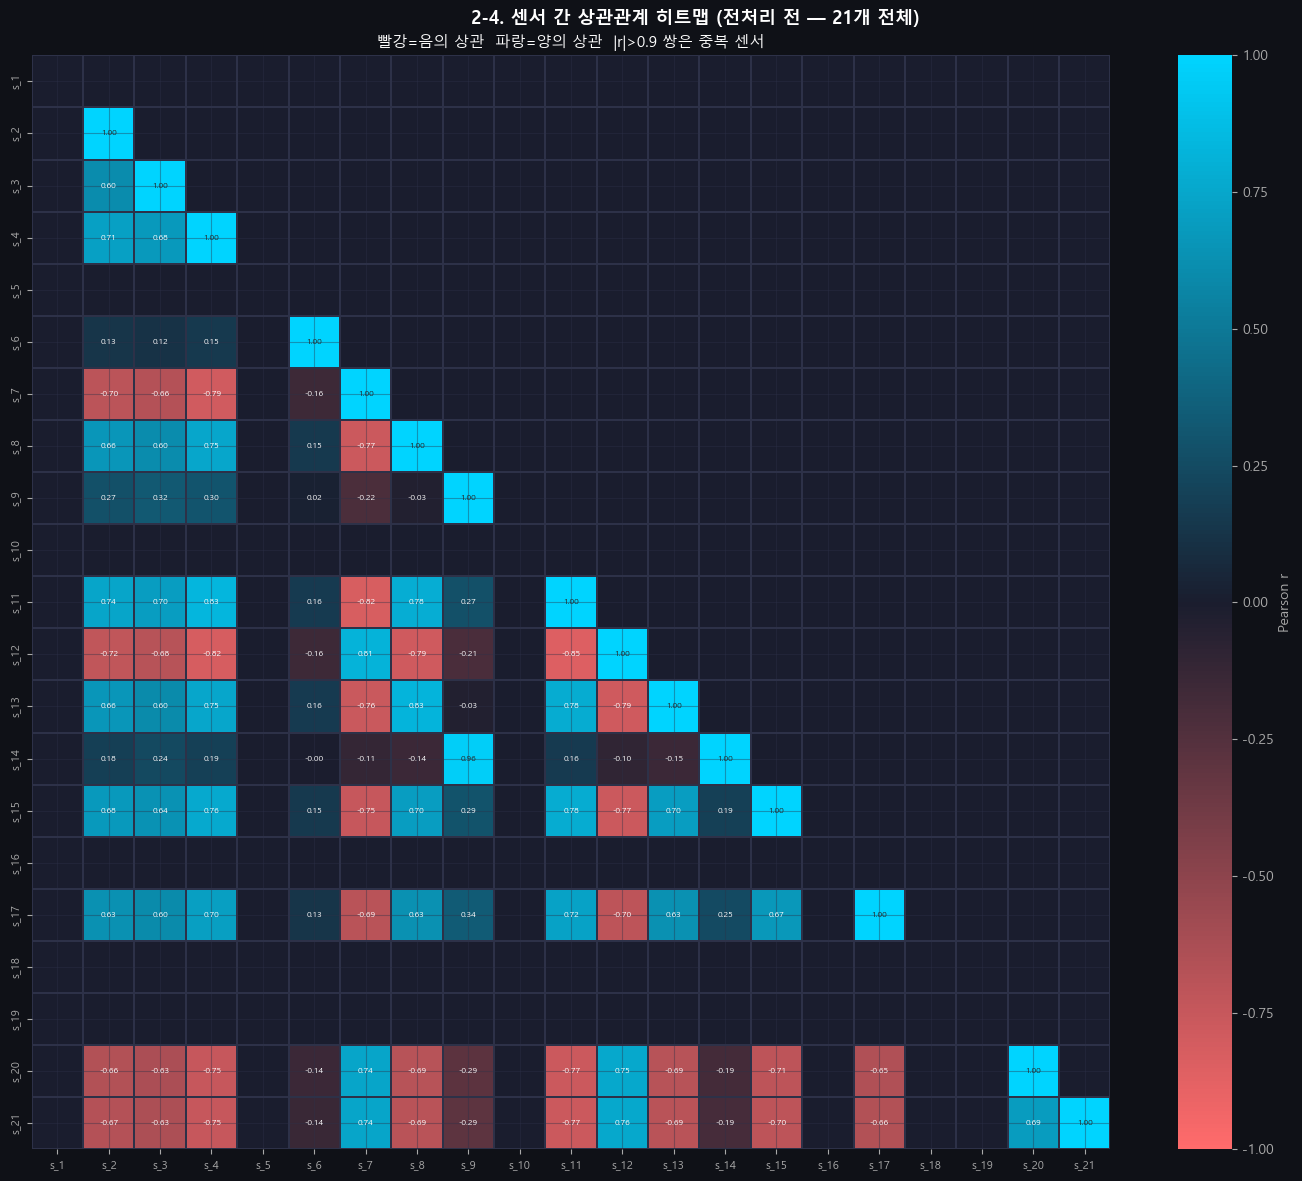

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_9,s_14,0.963


In [7]:
from matplotlib.colors import LinearSegmentedColormap

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# 고상관 쌍
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
if pairs:
    display(pd.DataFrame(pairs))
else:
    print('  해당 없음')

### 2-5. 센서별 열화 트렌드 (전처리 전)

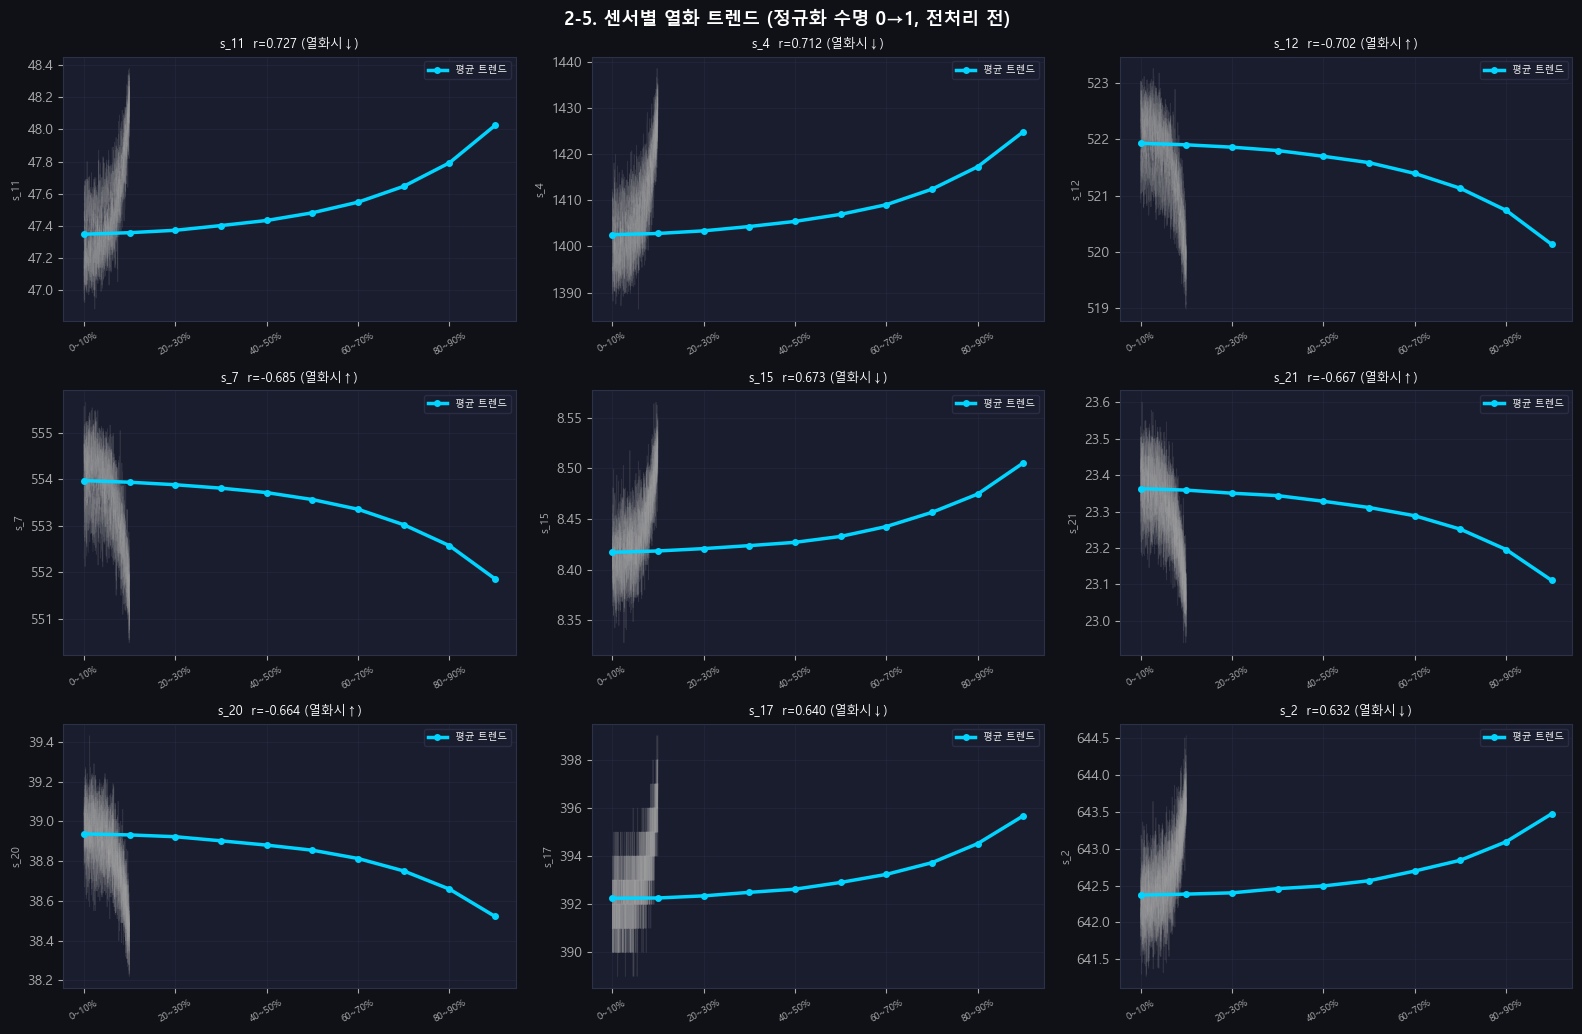

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [8]:
# 정규화 수명축(0=새것, 1=고장 직전)으로 평균 트렌드 확인
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 유의미한 트렌드 센서만 표시 (|corr|>0.1)
corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.1].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]  # 최대 9개

n_cols = 3
n_rows = (len(trend_sensors)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

x_pos = range(len(labels))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes.flat, trend_sensors):
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
    r = corr_with_life[s]
    direction = '열화시↑' if r<0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8)
    ax.legend(fontsize=7)

for ax in axes.flat[len(trend_sensors):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')

### 2-6. ADF 정상성 검정 (전처리 전)

> **ADF 검정 해석:**  
> `p < 0.05` → 비정상 시계열 → **트렌드(열화 신호) 존재** ← 우리가 원하는 결과  
> `p ≥ 0.05` → 정상 시계열 → 트렌드 없음 → RUL 예측에 부적합

=== 2-6. ADF 정상성 검정 (엔진 #1 기준, 전처리 전) ===


,p-value,판정
센서,,
s_1,NaN,계산불가
s_2,0.9816,정상⚠️ (트렌드 없음)
s_3,0.9854,정상⚠️ (트렌드 없음)
s_4,0.9903,정상⚠️ (트렌드 없음)
s_5,NaN,계산불가
s_6,NaN,계산불가
s_7,0.9984,정상⚠️ (트렌드 없음)
s_8,1.0000,정상⚠️ (트렌드 없음)
s_9,0.9811,정상⚠️ (트렌드 없음)


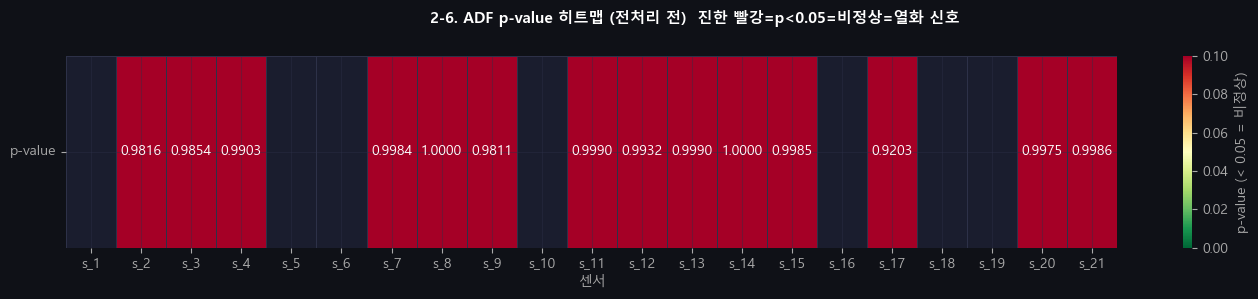


비정상 시계열(p<0.05): 0/21개 센서
📌 비정상 시계열 = 시간에 따라 체계적으로 변함 = 열화 신호 존재 = 슬라이딩 윈도우 적용 근거


In [9]:
print('=== 2-6. ADF 정상성 검정 (엔진 #1 기준, 전처리 전) ===')
unit1 = train_raw[train_raw['unit_nr']==1].sort_values('time_cycles')

adf_rows_before = []
for s in SENSOR_COLS:
    arr = unit1[s].dropna().values
    if len(arr) < 20:
        continue
    try:
        res = adfuller(arr, autolag='AIC')
        p   = round(res[1], 4)
        verdict = '비정상✅ (트렌드 있음)' if p<0.05 else '정상⚠️ (트렌드 없음)'
    except:
        p, verdict = np.nan, '계산불가'
    adf_rows_before.append({'센서':s,'p-value':p,'판정':verdict})

adf_before_df = pd.DataFrame(adf_rows_before).set_index('센서')
display(adf_before_df)

# 히트맵
fig, ax = plt.subplots(figsize=(14, 3))
fig.suptitle('2-6. ADF p-value 히트맵 (전처리 전)  진한 빨강=p<0.05=비정상=열화 신호', fontsize=11, fontweight='bold')
pivot = adf_before_df[['p-value']].T
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.1,
            annot=True, fmt='.4f', linewidths=0.5, linecolor=GRID,
            cbar_kws={'label':'p-value (< 0.05 = 비정상)'})
ax.set_yticklabels(['p-value'], rotation=0)
plt.tight_layout(); plt.show()

n_nonstat = (adf_before_df['p-value']<0.05).sum()
print(f'\n비정상 시계열(p<0.05): {n_nonstat}/{len(adf_before_df)}개 센서')
print('📌 비정상 시계열 = 시간에 따라 체계적으로 변함 = 열화 신호 존재 = 슬라이딩 윈도우 적용 근거')

### 2-7. RUL 상관계수 (전처리 전)

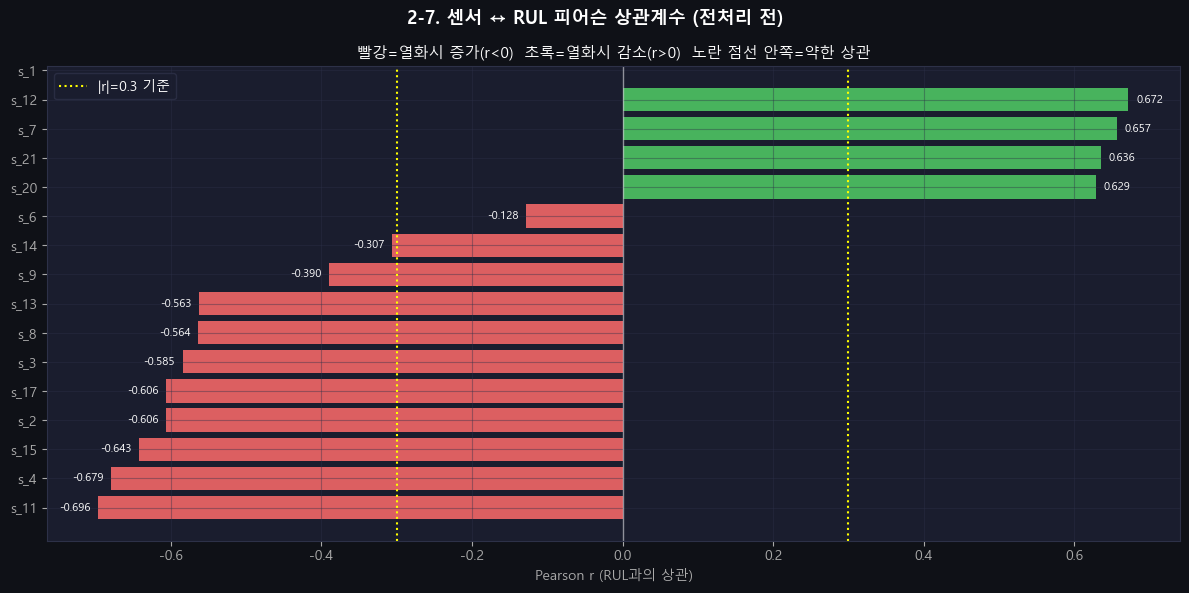

|r|>0.3 고상관 센서: 14개
  s_11: r=-0.696  Ps30 정적압력(psia)
  s_4: r=-0.679  T50 LPT 출구 온도(°R)
  s_12: r=0.672  phi 연료/Ps30 비율
  s_7: r=0.657  P30 HPC 출구 압력(psia)
  s_15: r=-0.643  BPR 바이패스 비율
  s_21: r=0.636  W32 LPT 냉각블리드
  s_20: r=0.629  W31 HPT 냉각블리드
  s_2: r=-0.606  T24 LPC 출구 온도(°R)
  s_17: r=-0.606  htBleed 블리드 엔탈피
  s_3: r=-0.585  T30 HPC 출구 온도(°R)
  s_8: r=-0.564  Nf 팬 속도(rpm)
  s_13: r=-0.563  NRf 보정 팬 속도(rpm)
  s_9: r=-0.390  Nc 코어 속도(rpm)
  s_14: r=-0.307  NRc 보정 코어속도(rpm)


In [10]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-7. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')

---
## 3. 결정 1 — 상수 센서 제거 (21개 → 14개)

**근거:** 비행 내내 값이 거의 변하지 않는 센서는 열화 정보를 담지 못함. 기준: `std < 0.01`  
> ⚠️ 기준은 **train**에서만 계산 → **동일 피처 목록**을 test에 적용 (누수 방지)

제거 (7개): ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
유지 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


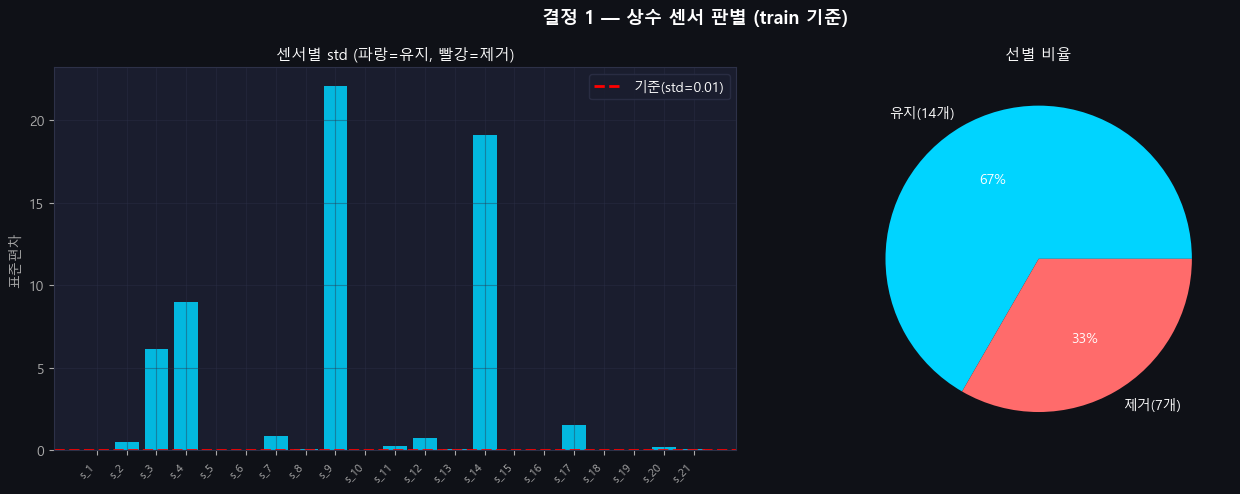


✅ 결정 1 완료: 26 → 19 컬럼


In [11]:
train_std      = train_raw[SENSOR_COLS].std()
USEFUL_SENSORS = train_std[train_std >= CONST_THR].index.tolist()
CONST_SENSORS  = train_std[train_std <  CONST_THR].index.tolist()

print(f'제거 ({len(CONST_SENSORS)}개): {CONST_SENSORS}')
print(f'유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 1 — 상수 센서 판별 (train 기준)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = [C[0] if s in USEFUL_SENSORS else C[1] for s in SENSOR_COLS]
ax.bar(range(len(SENSOR_COLS)), train_std.values, color=colors, alpha=0.85)
ax.axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준(std={CONST_THR})')
ax.set_xticks(range(len(SENSOR_COLS)))
ax.set_xticklabels(SENSOR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('표준편차')
ax.set_title('센서별 std (파랑=유지, 빨강=제거)')
ax.legend()

ax = axes[1]
ax.pie([len(USEFUL_SENSORS), len(CONST_SENSORS)],
       labels=[f'유지({len(USEFUL_SENSORS)}개)', f'제거({len(CONST_SENSORS)}개)'],
       colors=[C[0], C[1]], autopct='%1.0f%%',
       textprops={'color':WHITE})
ax.set_title('선별 비율')
plt.tight_layout(); plt.show()

# 적용 (train 기준 피처 → test에도 동일 적용)
KEEP = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()   # train 기준 피처 목록 그대로

print(f'\n✅ 결정 1 완료: {train_raw.shape[1]} → {train_s1.shape[1]} 컬럼')

## 4. 결정 2 — Piecewise RUL 생성 (Cap = 125)

**근거:** 100% 엔진이 수명 125 초과. 마지막 125 사이클(위험 구간)에만 모델이 집중하도록 함.  
> **train 전용** — test의 RUL은 `RUL_FD001.txt`에서 직접 가져옴

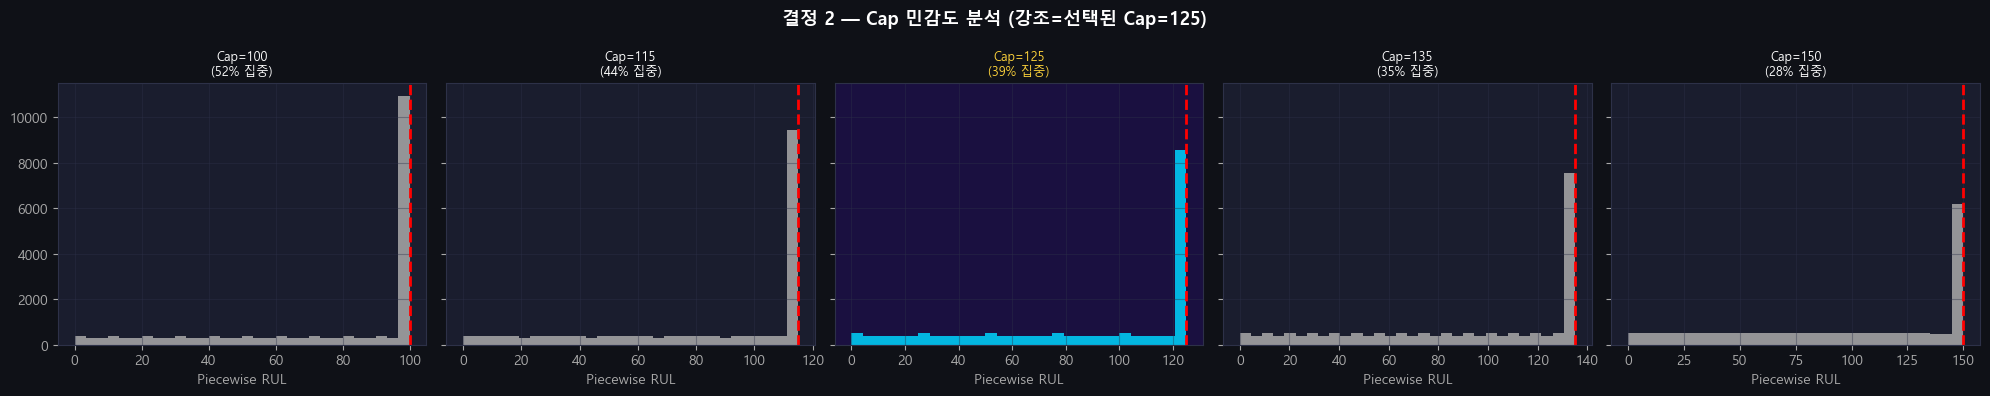

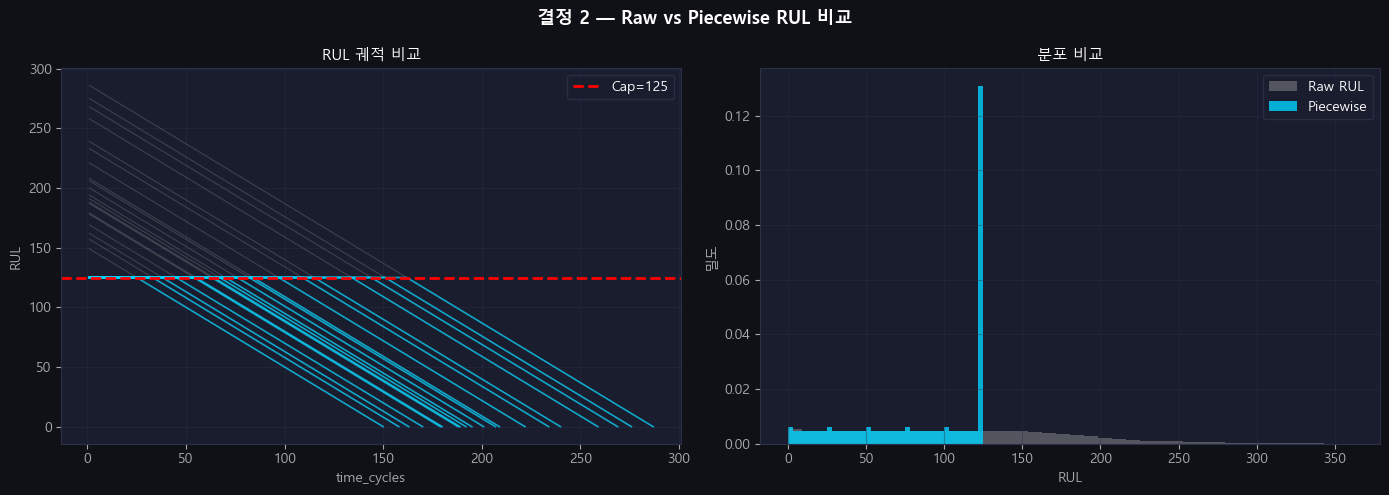

✅ 결정 2 완료  |  RUL std: 68.9 → 41.7 (39% 감소)


In [12]:
def add_piecewise_rul(df, cap=RUL_CAP):
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)

train_s2 = add_piecewise_rul(train_s1)
test_s2  = test_s1.copy()

# Cap 민감도 분석
caps = [100, 115, 125, 135, 150]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('결정 2 — Cap 민감도 분석 (강조=선택된 Cap=125)', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    tmp = train_s2['RUL_raw'].clip(upper=cap)
    pct = (train_s2['RUL_raw']>=cap).mean()*100
    ax.hist(tmp, bins=30, color=C[0] if cap==125 else GRAY, alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'Cap={cap}\n({pct:.0f}% 집중)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=9)
    ax.set_xlabel('Piecewise RUL')
    if cap==125: ax.patch.set_facecolor('#1a1040')
plt.tight_layout(); plt.show()

# 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('결정 2 — Raw vs Piecewise RUL 비교', fontsize=13, fontweight='bold')

ax = axes[0]
for u in train_s2['unit_nr'].unique()[:20]:
    sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
    ax.plot(sub['time_cycles'], sub['RUL_raw'], color=GRAY,  alpha=0.25, lw=0.8)
    ax.plot(sub['time_cycles'], sub['RUL'],     color=C[0], alpha=0.7,  lw=1.2)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL'); ax.set_title('RUL 궤적 비교'); ax.legend()

ax = axes[1]
ax.hist(train_s2['RUL_raw'], bins=40, alpha=0.4, color=GRAY,  density=True, label='Raw RUL')
ax.hist(train_s2['RUL'],     bins=40, alpha=0.8, color=C[0], density=True, label='Piecewise')
ax.set_xlabel('RUL'); ax.set_ylabel('밀도'); ax.set_title('분포 비교'); ax.legend()
plt.tight_layout(); plt.show()

raw_std, piece_std = train_s2['RUL_raw'].std(), train_s2['RUL'].std()
print(f'✅ 결정 2 완료  |  RUL std: {raw_std:.1f} → {piece_std:.1f} ({(1-piece_std/raw_std)*100:.0f}% 감소)')

## 5. 결정 3 — MinMax 정규화

**근거:** 센서마다 스케일이 달라 학습이 불안정해짐. FD001은 단일 조건이므로 MinMaxScaler 1개.  
> ⚠️ **fit은 train만** — test에는 transform만 적용

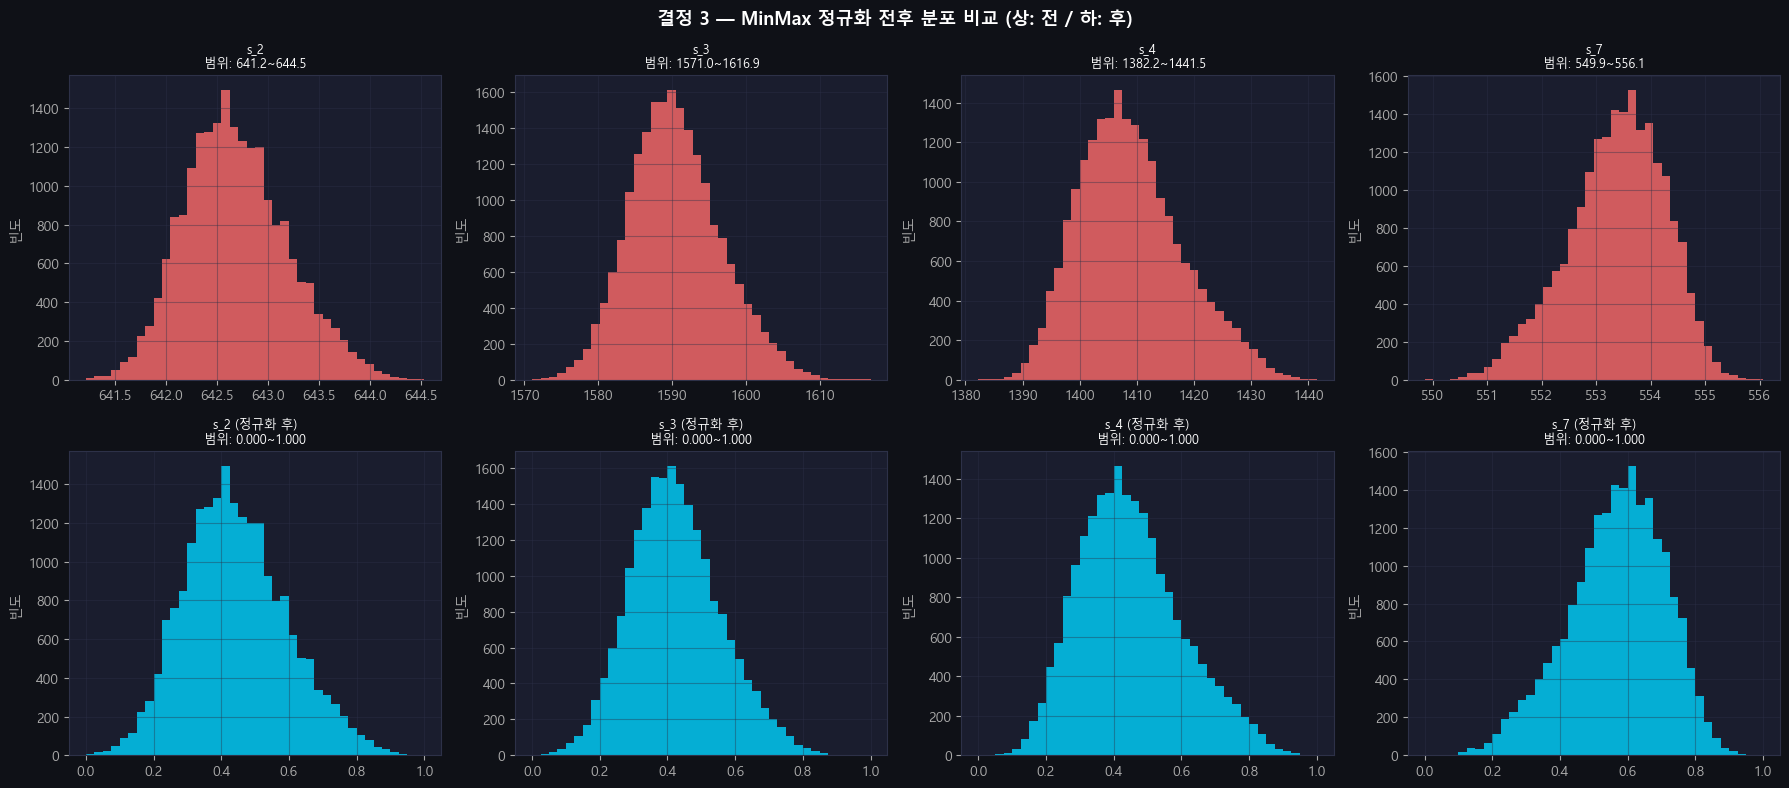

--- 정규화 전후 범위 비교 ---


,전_min,전_max,후_min,후_max
s_2,641.2100,644.5300,0.0,1.0
s_3,1571.0400,1616.9100,0.0,1.0
s_4,1382.2500,1441.4900,0.0,1.0
s_7,549.8500,556.0600,0.0,1.0
s_8,2387.9000,2388.5600,0.0,1.0
s_9,9021.7300,9244.5900,0.0,1.0
s_11,46.8500,48.5300,0.0,1.0
s_12,518.6900,523.3800,0.0,1.0
s_13,2387.8800,2388.5600,0.0,1.0
s_14,8099.9400,8293.7200,0.0,1.0



✅ 결정 3 완료  |  전체 센서 범위: 0.0000 ~ 1.0000


In [13]:
# 정규화 전 범위 기록
before_min = train_s2[USEFUL_SENSORS].min()
before_max = train_s2[USEFUL_SENSORS].max()

scaler = MinMaxScaler()
train_s3 = train_s2.copy()
test_s3  = test_s2.copy()

scaler.fit(train_s3[USEFUL_SENSORS])                              # fit: train만
train_s3[USEFUL_SENSORS] = scaler.transform(train_s3[USEFUL_SENSORS])
test_s3[USEFUL_SENSORS]  = scaler.transform(test_s3[USEFUL_SENSORS])

# 전후 비교 시각화 (4개 센서 대표)
show4 = USEFUL_SENSORS[:4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('결정 3 — MinMax 정규화 전후 분포 비교 (상: 전 / 하: 후)', fontsize=13, fontweight='bold')

for col, s in enumerate(show4):
    ax_b = axes[0, col]
    ax_a = axes[1, col]
    b = train_s2[s]
    a = train_s3[s]
    ax_b.hist(b, bins=40, color=C[1], alpha=0.8, edgecolor='none')
    ax_b.set_title(f'{s}\n범위: {b.min():.1f}~{b.max():.1f}', fontsize=9)
    ax_b.set_ylabel('빈도')
    ax_a.hist(a, bins=40, color=C[0], alpha=0.8, edgecolor='none')
    ax_a.set_title(f'{s} (정규화 후)\n범위: {a.min():.3f}~{a.max():.3f}', fontsize=9)
    ax_a.set_ylabel('빈도')

plt.tight_layout(); plt.show()

# 정규화 후 범위 확인 표
range_df = pd.DataFrame({
    '전_min': before_min, '전_max': before_max,
    '후_min': train_s3[USEFUL_SENSORS].min(),
    '후_max': train_s3[USEFUL_SENSORS].max(),
})
print('--- 정규화 전후 범위 비교 ---')
display(range_df.round(4))
print(f'\n✅ 결정 3 완료  |  전체 센서 범위: 0.0000 ~ 1.0000')

## 6. 결정 4 — Gaussian 스무딩 (σ = 2)

**근거:** 시뮬레이션 노이즈 제거, 열화 트렌드만 추출.  
> `mode='nearest'` — test의 짧은 시계열에서 발생하는 경계 효과 최소화

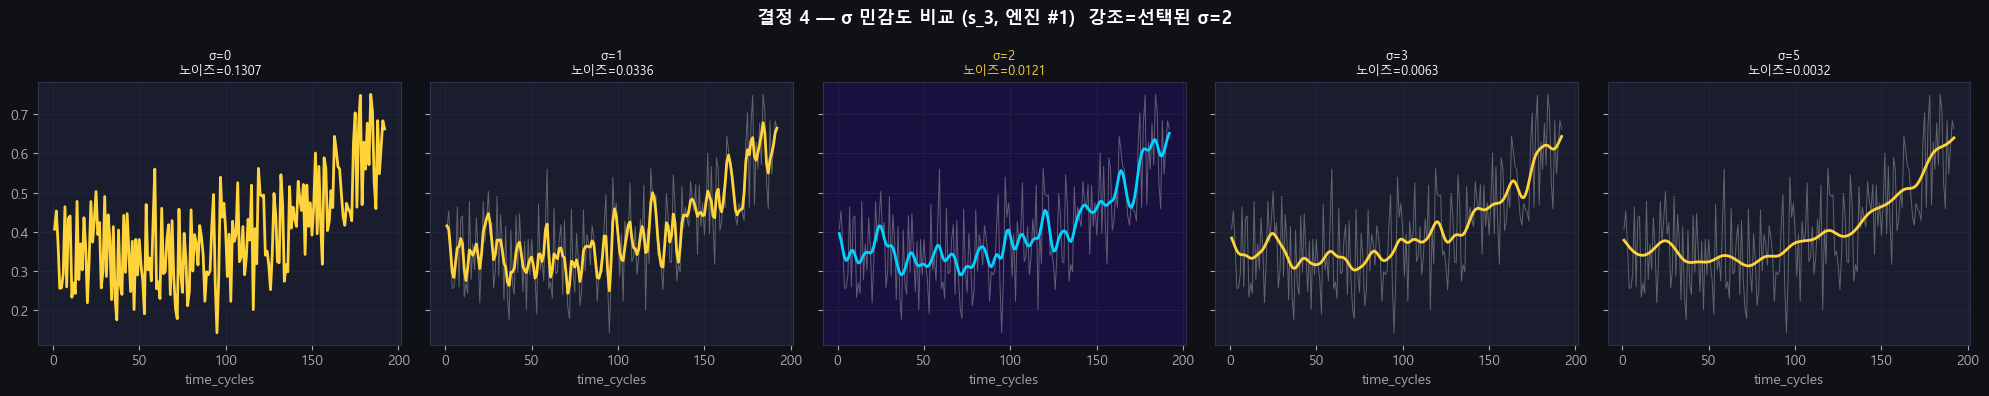

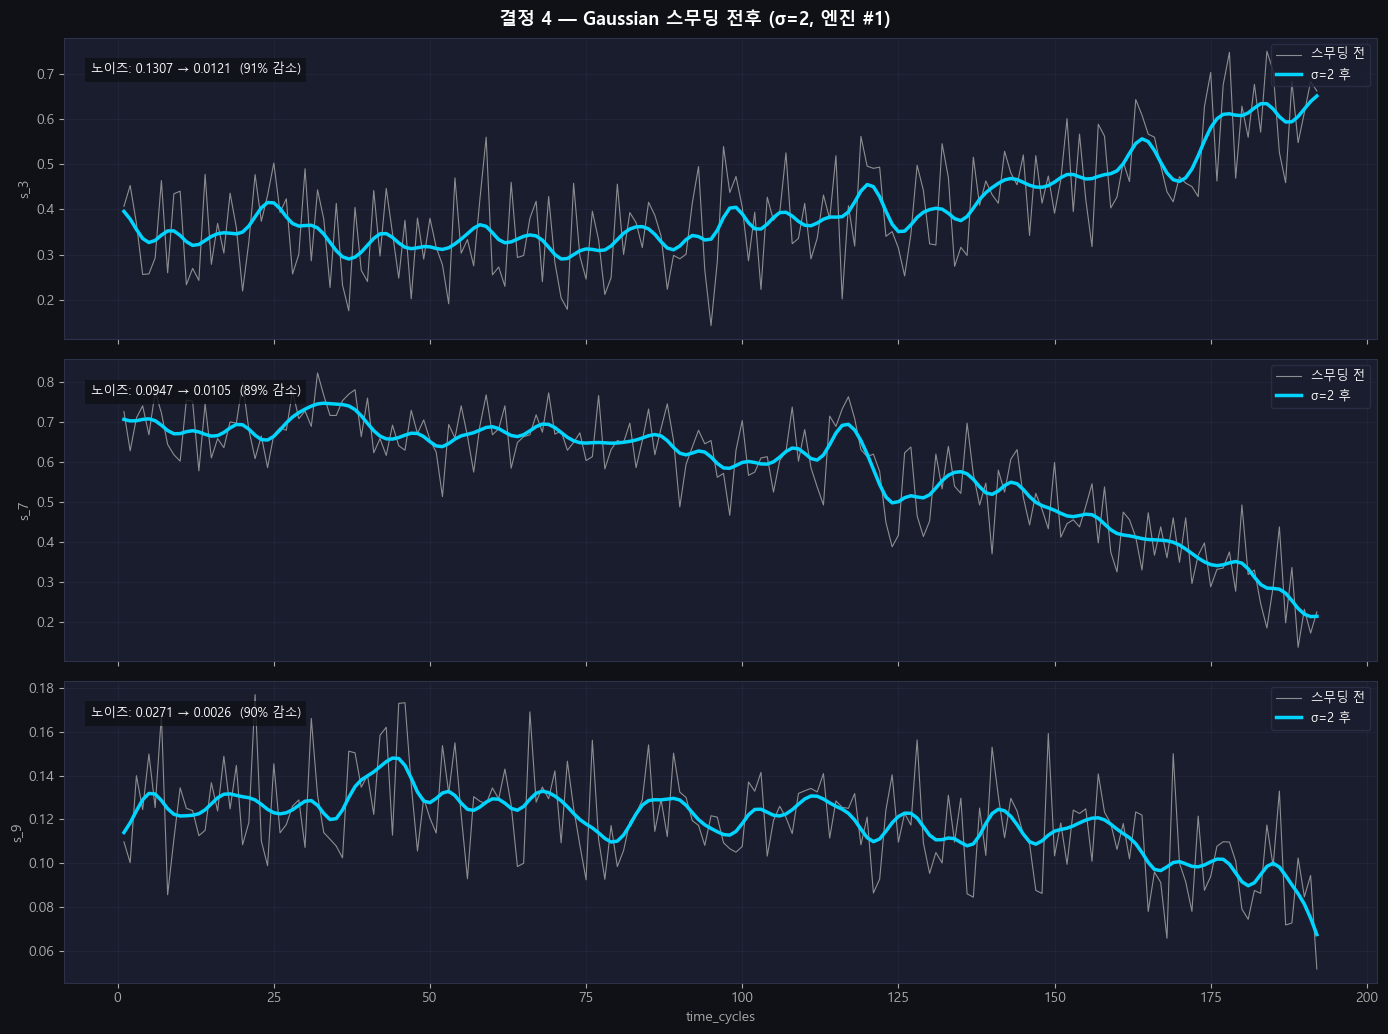

✅ 결정 4 완료  (σ=2, mode=nearest)


In [14]:
def apply_gaussian(df, features, sigma=GAUSS_SIGMA):
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    df[features] = df[features].astype(np.float32)
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in features:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

train_s4 = apply_gaussian(train_s3, USEFUL_SENSORS)
test_s4  = apply_gaussian(test_s3,  USEFUL_SENSORS)

# σ 민감도 (엔진 #1, 대표 센서)
unit1_norm = train_s3[train_s3['unit_nr']==1].sort_values('time_cycles')
s_ex = 's_3' if 's_3' in USEFUL_SENSORS else USEFUL_SENSORS[0]
sigmas = [0, 1, 2, 3, 5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle(f'결정 4 — σ 민감도 비교 ({s_ex}, 엔진 #1)  강조=선택된 σ=2', fontsize=13, fontweight='bold')

for ax, sig in zip(axes, sigmas):
    y_raw = unit1_norm[s_ex].values
    y_f   = gaussian_filter1d(y_raw, sigma=sig, mode='nearest') if sig>0 else y_raw
    noise = np.std(np.diff(y_f))
    ax.plot(unit1_norm['time_cycles'], y_raw, color=GRAY, alpha=0.5, lw=0.7, label='원본')
    ax.plot(unit1_norm['time_cycles'], y_f,   color=C[0] if sig==GAUSS_SIGMA else C[3], lw=2)
    ax.set_title(f'σ={sig}\n노이즈={noise:.4f}',
                 color='#ffd43b' if sig==GAUSS_SIGMA else WHITE, fontsize=9)
    if sig==GAUSS_SIGMA: ax.patch.set_facecolor('#1a1040')
    ax.set_xlabel('time_cycles')

plt.tight_layout(); plt.show()

# 전후 비교 (3개 센서)
show3 = [s for s in ['s_3','s_7','s_9'] if s in USEFUL_SENSORS]
if len(show3) < 2: show3 = USEFUL_SENSORS[:3]

unit1_before = train_s3[train_s3['unit_nr']==1].sort_values('time_cycles')
unit1_after  = train_s4[train_s4['unit_nr']==1].sort_values('time_cycles')

fig, axes = plt.subplots(len(show3), 1, figsize=(14, 3.5*len(show3)), sharex=True)
if len(show3)==1: axes=[axes]
fig.suptitle(f'결정 4 — Gaussian 스무딩 전후 (σ={GAUSS_SIGMA}, 엔진 #1)', fontsize=13, fontweight='bold')

for ax, s in zip(axes, show3):
    ax.plot(unit1_before['time_cycles'], unit1_before[s], color=GRAY, lw=0.8, alpha=0.8, label='스무딩 전')
    ax.plot(unit1_after['time_cycles'],  unit1_after[s],  color=C[0], lw=2.5,             label=f'σ={GAUSS_SIGMA} 후')
    nb = np.std(np.diff(unit1_before[s].values))
    na = np.std(np.diff(unit1_after[s].values))
    pct = (1-na/nb)*100 if nb>0 else 0
    ax.text(0.02, 0.88, f'노이즈: {nb:.4f} → {na:.4f}  ({pct:.0f}% 감소)',
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor=BG, alpha=0.8, edgecolor='none'))
    ax.set_ylabel(s); ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('time_cycles')
plt.tight_layout(); plt.show()
print(f'✅ 결정 4 완료  (σ={GAUSS_SIGMA}, mode=nearest)')

---
## 7. 전처리 후 검증 — 전처리 전후 비교
### 7-1. 상관관계 히트맵 전후 비교

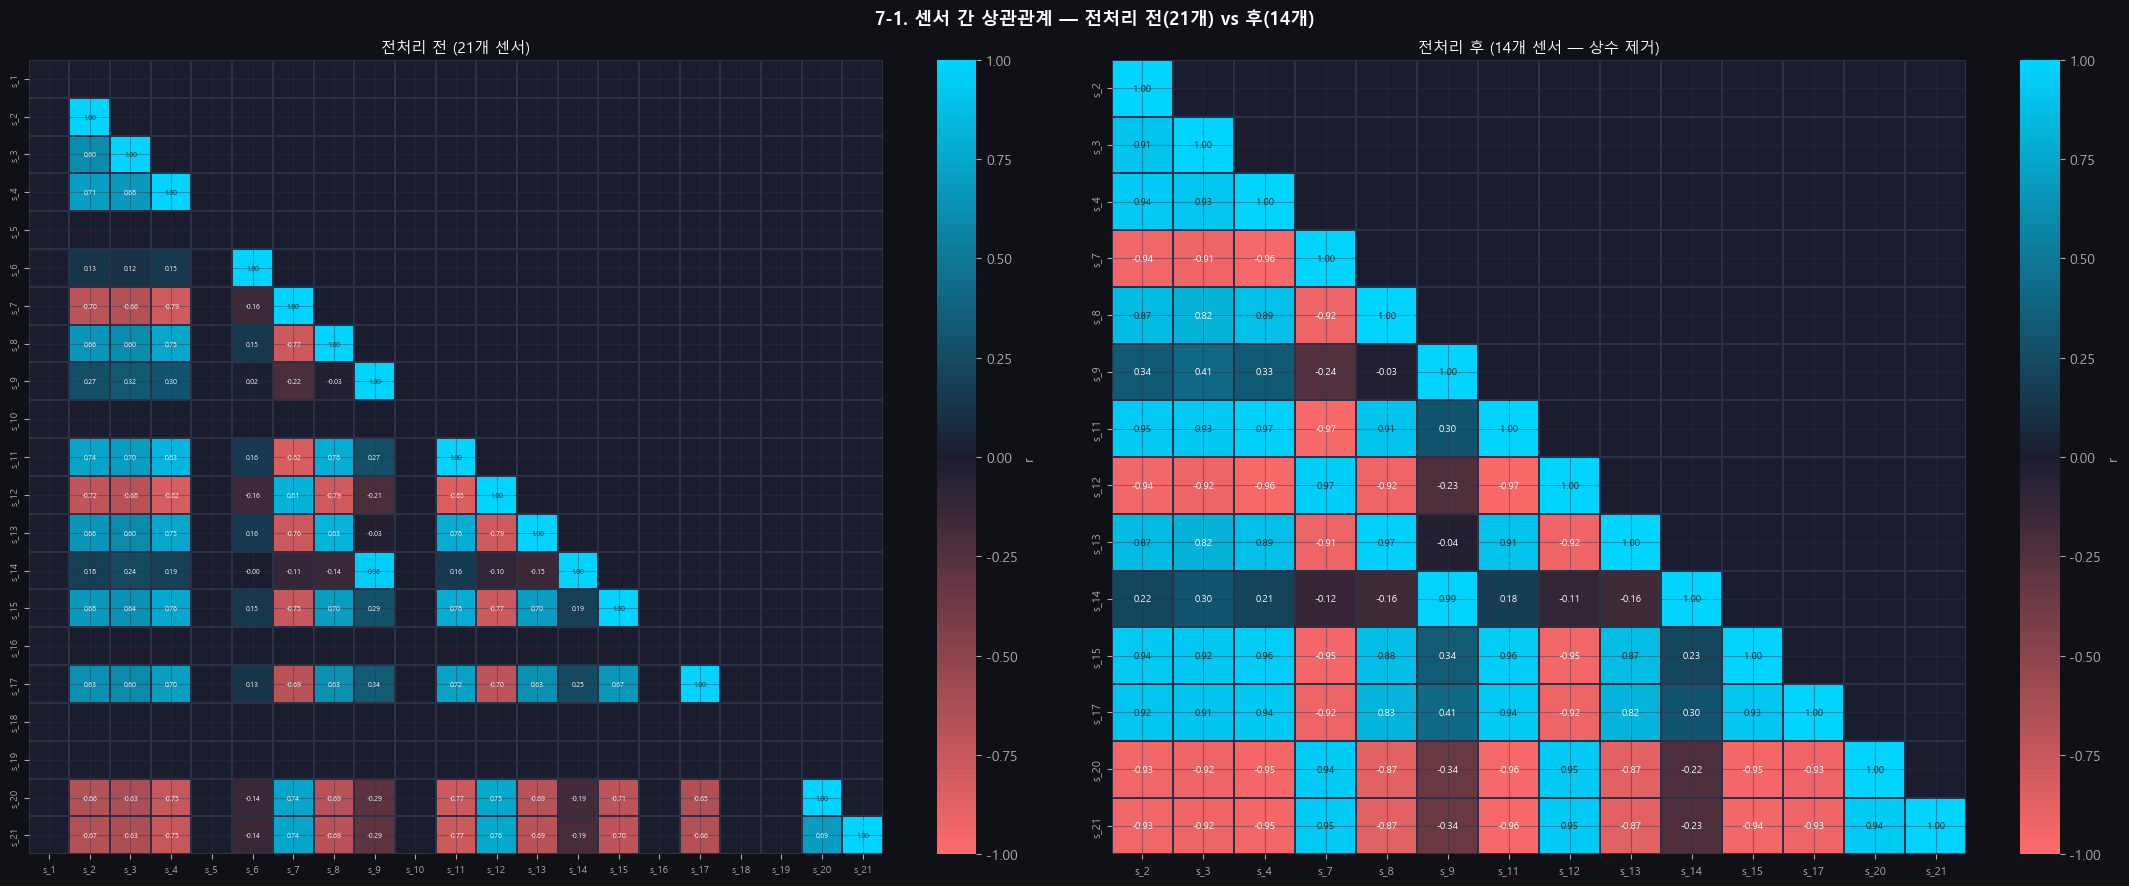

고상관 쌍(|r|>0.9): 전처리 전 1개 → 후 53개


,센서A,센서B,r
0,s_2,s_3,0.912
1,s_2,s_4,0.945
2,s_2,s_7,-0.937
3,s_2,s_11,0.950
4,s_2,s_12,-0.941
5,s_2,s_15,0.936
6,s_2,s_17,0.919
7,s_2,s_20,-0.931
8,s_2,s_21,-0.934
9,s_3,s_4,0.929


In [15]:
corr_after = train_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('7-1. 센서 간 상관관계 — 전처리 전(21개) vs 후(14개)', fontsize=13, fontweight='bold')

# 전 (21개)
mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':5}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'r'})
axes[0].set_title('전처리 전 (21개 센서)', fontsize=11)
axes[0].tick_params(labelsize=7)

# 후 (14개)
mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':7}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'r'})
axes[1].set_title('전처리 후 (14개 센서 — 상수 제거)', fontsize=11)
axes[1].tick_params(labelsize=8)

plt.tight_layout(); plt.show()

# 고상관 쌍 변화
pairs_after = []
for i in range(len(USEFUL_SENSORS)):
    for j in range(i+1, len(USEFUL_SENSORS)):
        r = corr_after.iloc[i,j]
        if abs(r)>0.9:
            pairs_after.append({'센서A':USEFUL_SENSORS[i],'센서B':USEFUL_SENSORS[j],'r':round(r,3)})
print(f'고상관 쌍(|r|>0.9): 전처리 전 {len(pairs)}개 → 후 {len(pairs_after)}개')
if pairs_after: display(pd.DataFrame(pairs_after))

### 7-2. ADF 정상성 검정 전후 비교

=== 7-2. ADF 검정 전후 비교 (엔진 #1) ===


,p-value(전),p-value(후),판정(후)
센서,,,
s_2,0.9816,0.9974,정상⚠️
s_3,0.9854,1.0000,정상⚠️
s_4,0.9903,0.9990,정상⚠️
s_7,0.9984,0.9991,정상⚠️
s_8,1.0000,1.0000,정상⚠️
s_9,0.9811,0.9991,정상⚠️
s_11,0.9990,1.0000,정상⚠️
s_12,0.9932,0.9990,정상⚠️
s_13,0.9990,1.0000,정상⚠️


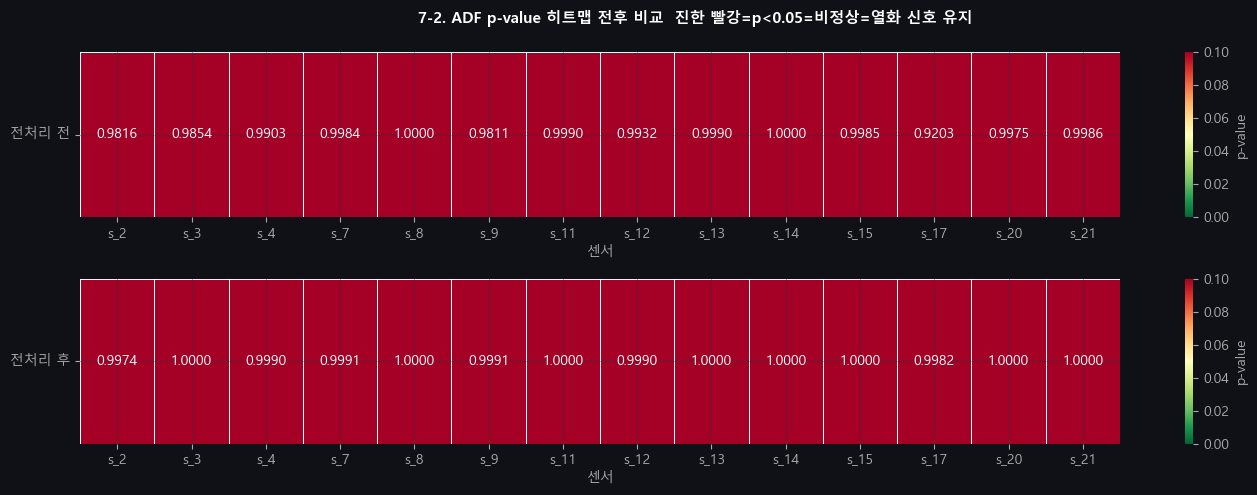


비정상 시계열 수 (p<0.05): 전처리 전 0개 → 후 0개
📌 스무딩 후에도 비정상 시계열이 유지 = 열화 트렌드는 보존됨


In [16]:
print('=== 7-2. ADF 검정 전후 비교 (엔진 #1) ===')

unit1_after_df = train_s4[train_s4['unit_nr']==1].sort_values('time_cycles')

adf_rows_after = []
for s in USEFUL_SENSORS:
    arr = unit1_after_df[s].dropna().values
    if len(arr)<20: continue
    try:
        res = adfuller(arr, autolag='AIC')
        p   = round(res[1], 4)
        verdict = '비정상✅' if p<0.05 else '정상⚠️'
    except:
        p, verdict = np.nan, '계산불가'
    adf_rows_after.append({'센서':s,'p-value(후)':p,'판정(후)':verdict})

adf_after_df = pd.DataFrame(adf_rows_after).set_index('센서')

# 전처리 전 p-value 중 유용 센서만
adf_before_useful = adf_before_df.loc[adf_before_df.index.isin(USEFUL_SENSORS), ['p-value']]\
                    .rename(columns={'p-value':'p-value(전)'})

compare_adf = adf_before_useful.join(adf_after_df, how='inner')
display(compare_adf)

# 히트맵 전후 비교
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
fig.suptitle('7-2. ADF p-value 히트맵 전후 비교  진한 빨강=p<0.05=비정상=열화 신호 유지', fontsize=11, fontweight='bold')

sns.heatmap(compare_adf[['p-value(전)']].T, ax=axes[0], cmap='RdYlGn_r',
            vmin=0, vmax=0.1, annot=True, fmt='.4f', linewidths=0.5,
            cbar_kws={'label':'p-value'})
axes[0].set_yticklabels(['전처리 전'], rotation=0)

sns.heatmap(compare_adf[['p-value(후)']].T, ax=axes[1], cmap='RdYlGn_r',
            vmin=0, vmax=0.1, annot=True, fmt='.4f', linewidths=0.5,
            cbar_kws={'label':'p-value'})
axes[1].set_yticklabels(['전처리 후'], rotation=0)

plt.tight_layout(); plt.show()

n_before = (compare_adf['p-value(전)']<0.05).sum()
n_after  = (compare_adf['p-value(후)']<0.05).sum()
print(f'\n비정상 시계열 수 (p<0.05): 전처리 전 {n_before}개 → 후 {n_after}개')
print('📌 스무딩 후에도 비정상 시계열이 유지 = 열화 트렌드는 보존됨')

### 7-3. 센서 분포 전후 비교 (유용 센서 전체)

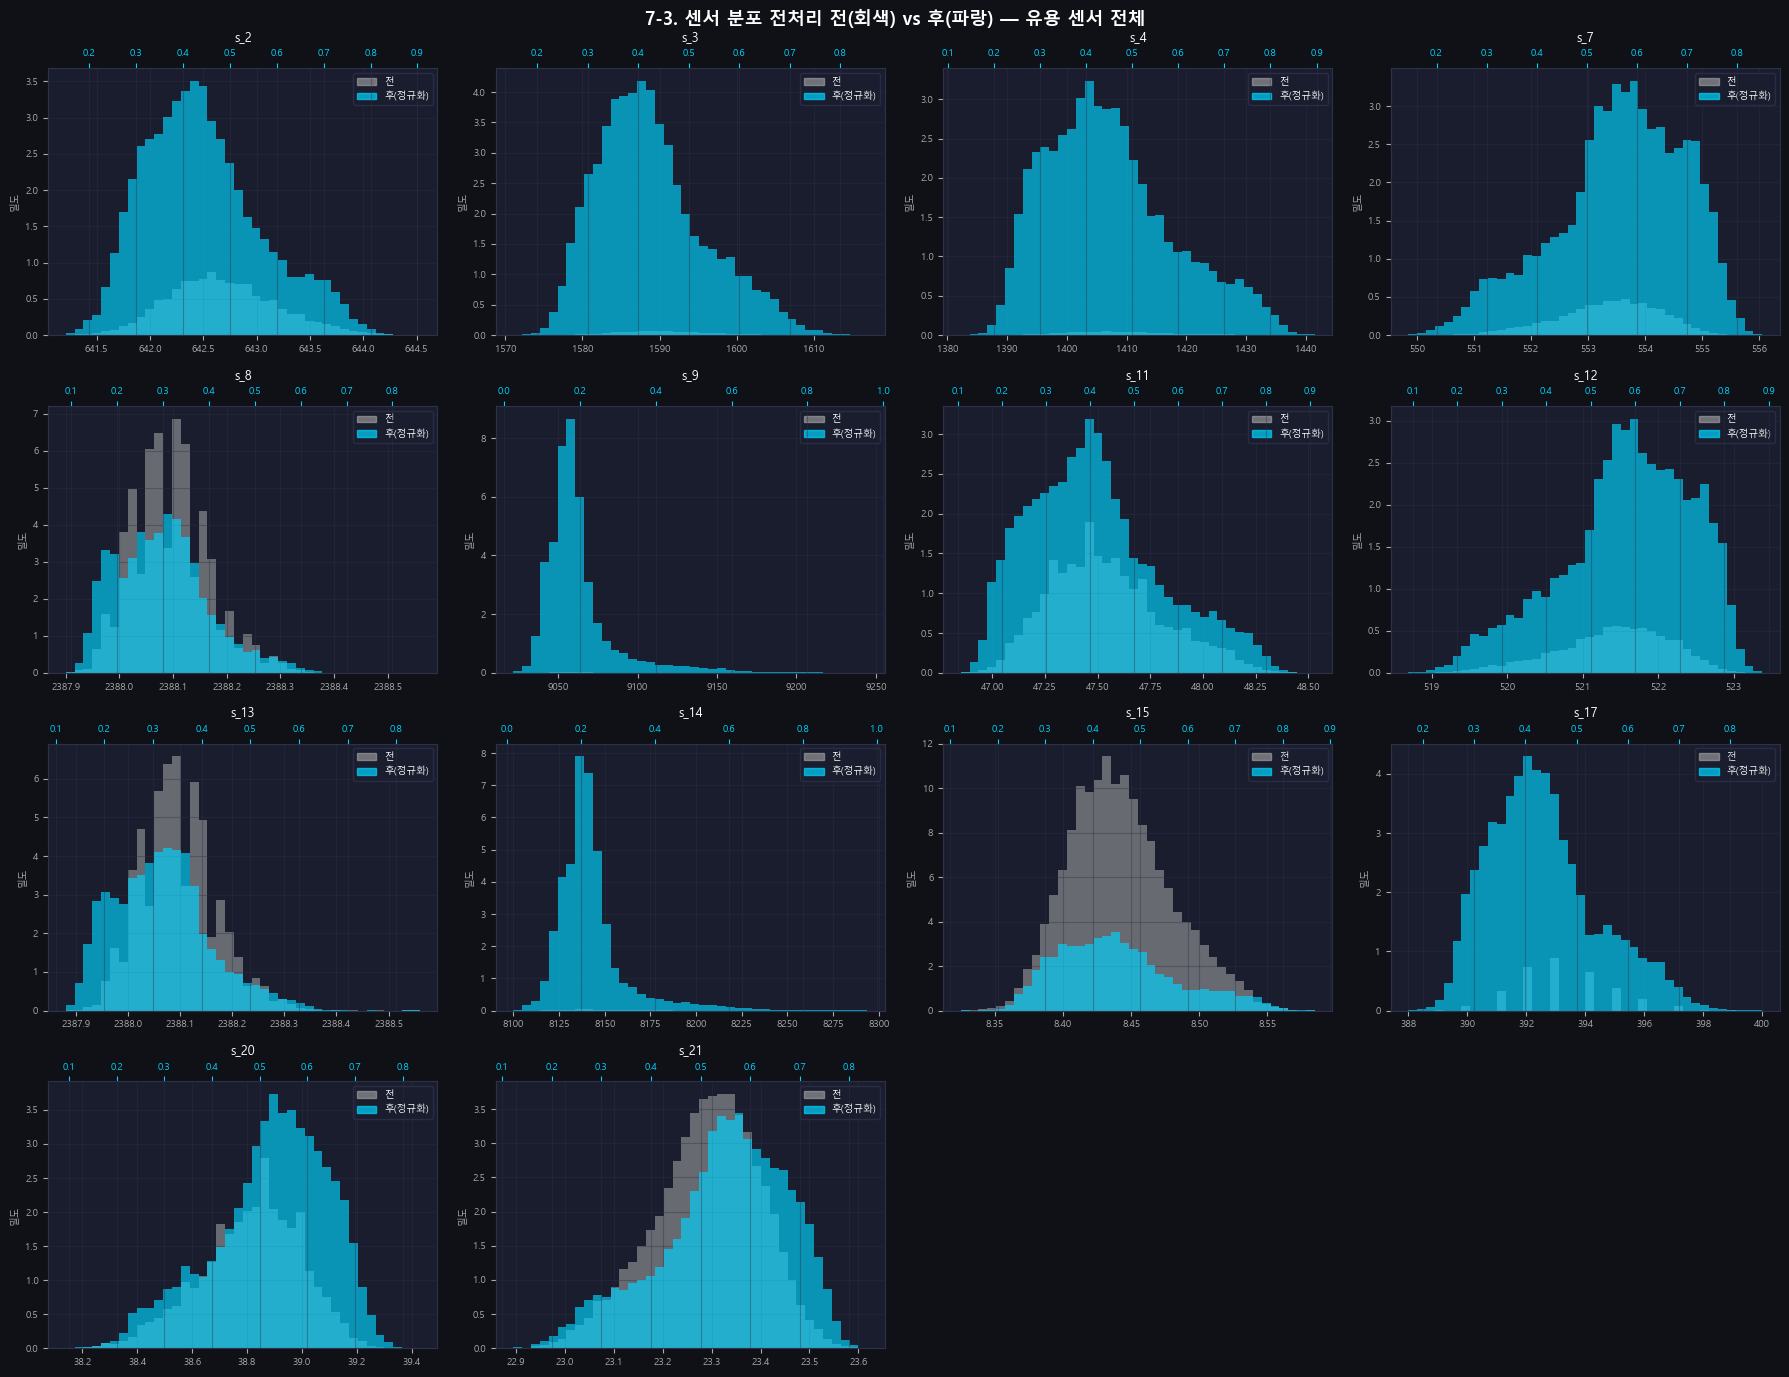

In [17]:
n_cols = 4
n_rows = (len(USEFUL_SENSORS)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5))
fig.suptitle('7-3. 센서 분포 전처리 전(회색) vs 후(파랑) — 유용 센서 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    before_data = train_s2[s]
    after_data  = train_s4[s]
    # 정규화된 값이라 x축 스케일이 다름 → 별도 정규화
    ax2 = ax.twiny()
    ax.hist(before_data, bins=40, color=GRAY,  alpha=0.55, density=True, label='전처리 전')
    ax2.hist(after_data, bins=40, color=C[0], alpha=0.65, density=True, label='전처리 후')
    ax.set_title(f'{s}', fontsize=9)
    ax.set_ylabel('밀도', fontsize=7)
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7, colors=C[0])
    handles = [mpatches.Patch(color=GRAY, alpha=0.6, label='전'),
               mpatches.Patch(color=C[0], alpha=0.7, label='후(정규화)')]
    ax.legend(handles=handles, fontsize=7, loc='upper right')

for ax in axes.flat[len(USEFUL_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

### 7-4. Train vs Test 분포 비교 (전처리 후)

=== 7-4. Train vs Test 분포 비교 (전처리 후, KS 검정) ===

KS 검정: p>0.05 → 두 분포 유사  |  p≤0.05 → 분포 차이 (설계상 정상)


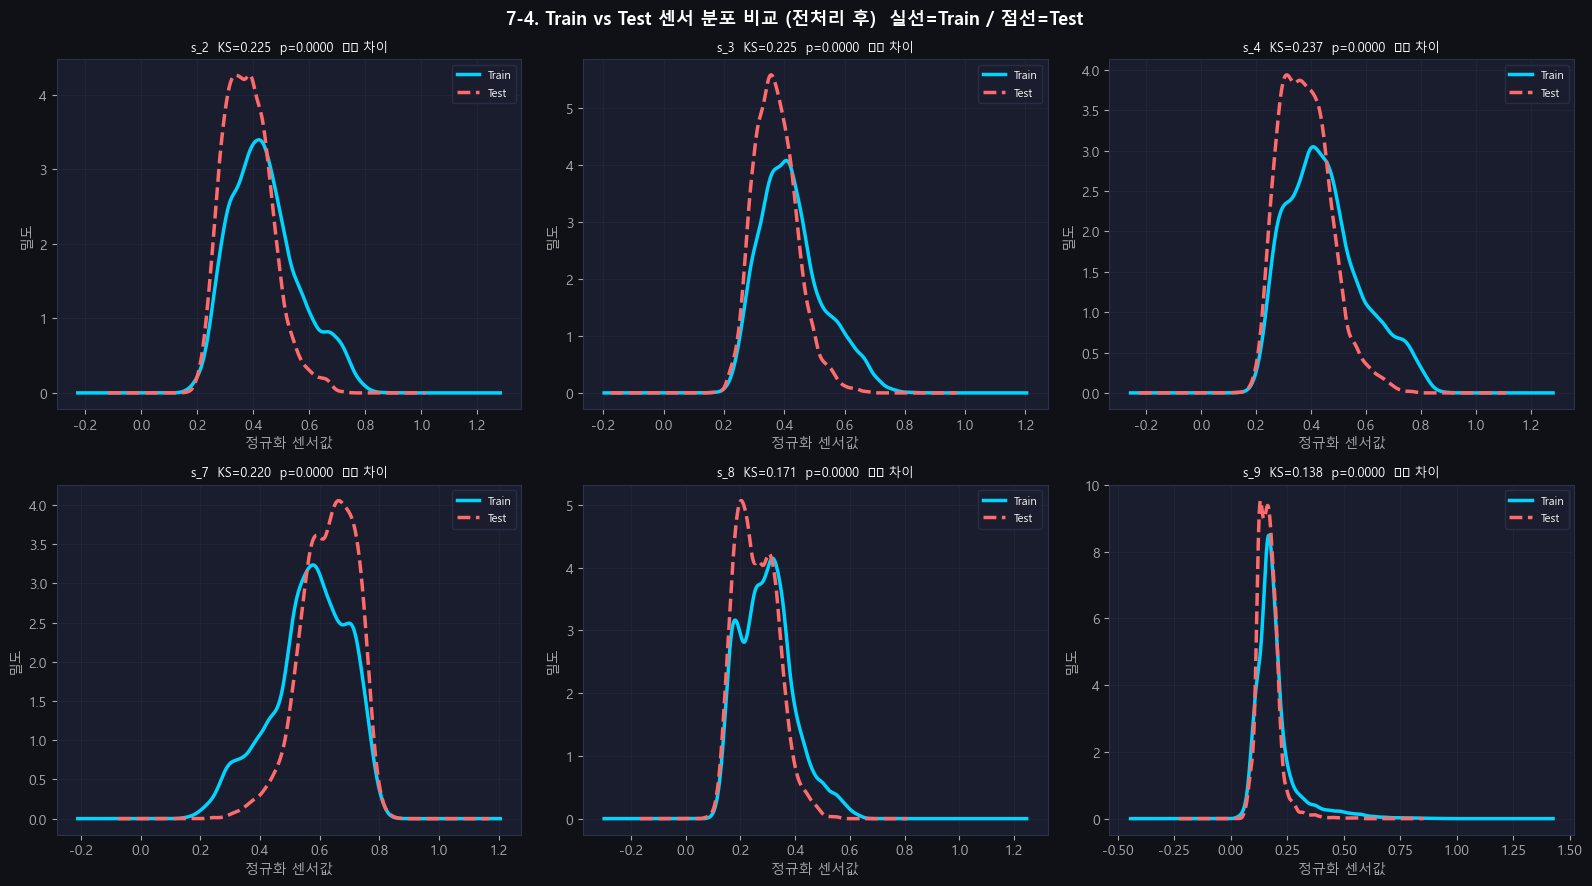


KS 검정 결과 요약:


,KS통계량,p-value,판정
센서,,,
s_2,0.2251,0.0,⚠️ 차이
s_3,0.2248,0.0,⚠️ 차이
s_4,0.2369,0.0,⚠️ 차이
s_7,0.2201,0.0,⚠️ 차이
s_8,0.1713,0.0,⚠️ 차이
s_9,0.1384,0.0,⚠️ 차이



📌 Train은 고장까지 전체 기록 → 극단값 포함
   Test는 고장 전 일정 시점에서 끊김 → 극단값 없음
   분포 차이는 데이터셋 설계 특성이며 문제가 아님


In [18]:
print('=== 7-4. Train vs Test 분포 비교 (전처리 후, KS 검정) ===')
print()
print('KS 검정: p>0.05 → 두 분포 유사  |  p≤0.05 → 분포 차이 (설계상 정상)')

show6 = USEFUL_SENSORS[:6]
ks_rows = []

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('7-4. Train vs Test 센서 분포 비교 (전처리 후)  실선=Train / 점선=Test', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show6):
    tr_v = train_s4[s].dropna()
    te_v = test_s4[s].dropna()
    try:
        tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Train')
        te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서':s,'KS통계량':round(ks_stat,4),'p-value':round(ks_p,4),'판정':verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  p={ks_p:.4f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print('\nKS 검정 결과 요약:')
display(pd.DataFrame(ks_rows).set_index('센서'))
print()
print('📌 Train은 고장까지 전체 기록 → 극단값 포함')
print('   Test는 고장 전 일정 시점에서 끊김 → 극단값 없음')
print('   분포 차이는 데이터셋 설계 특성이며 문제가 아님')

### 7-5. 열화 트렌드 전후 비교 + RUL 상관계수 변화

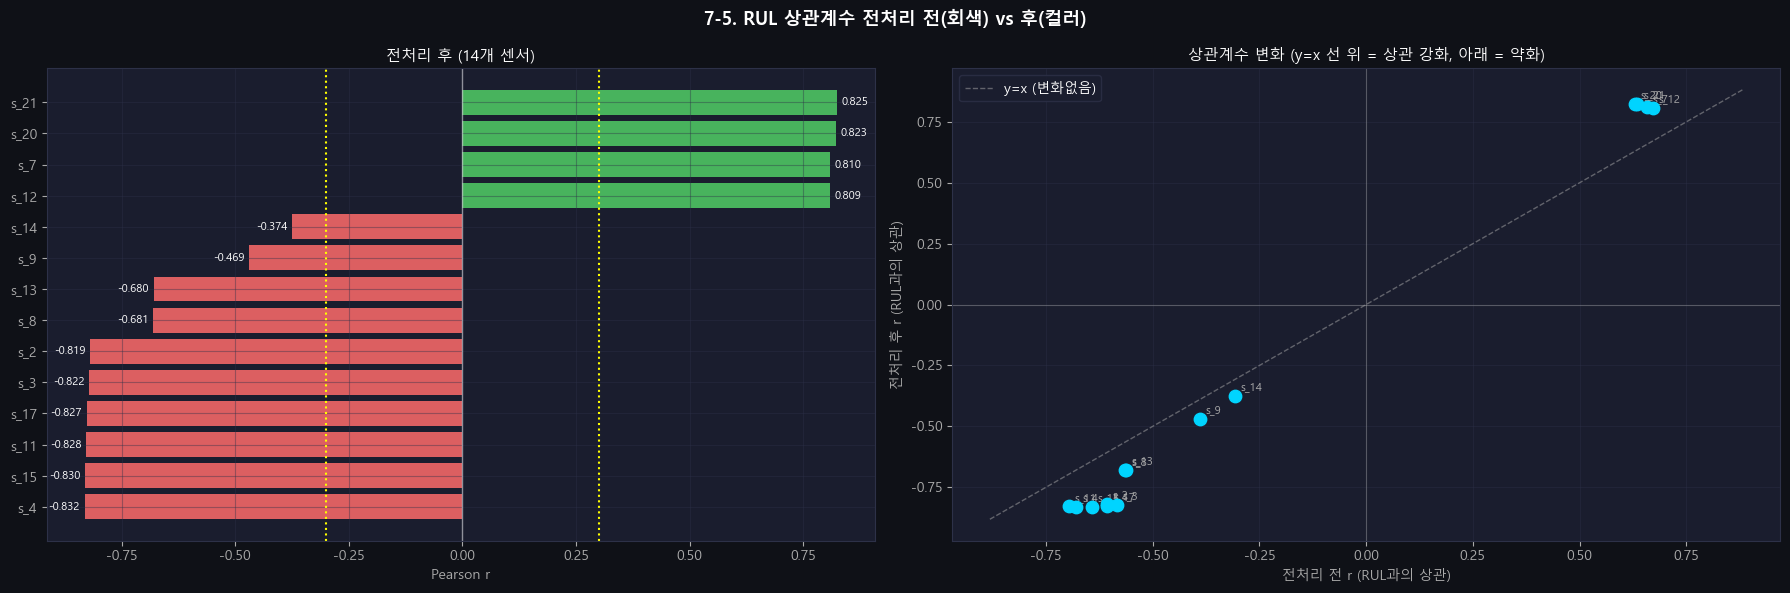

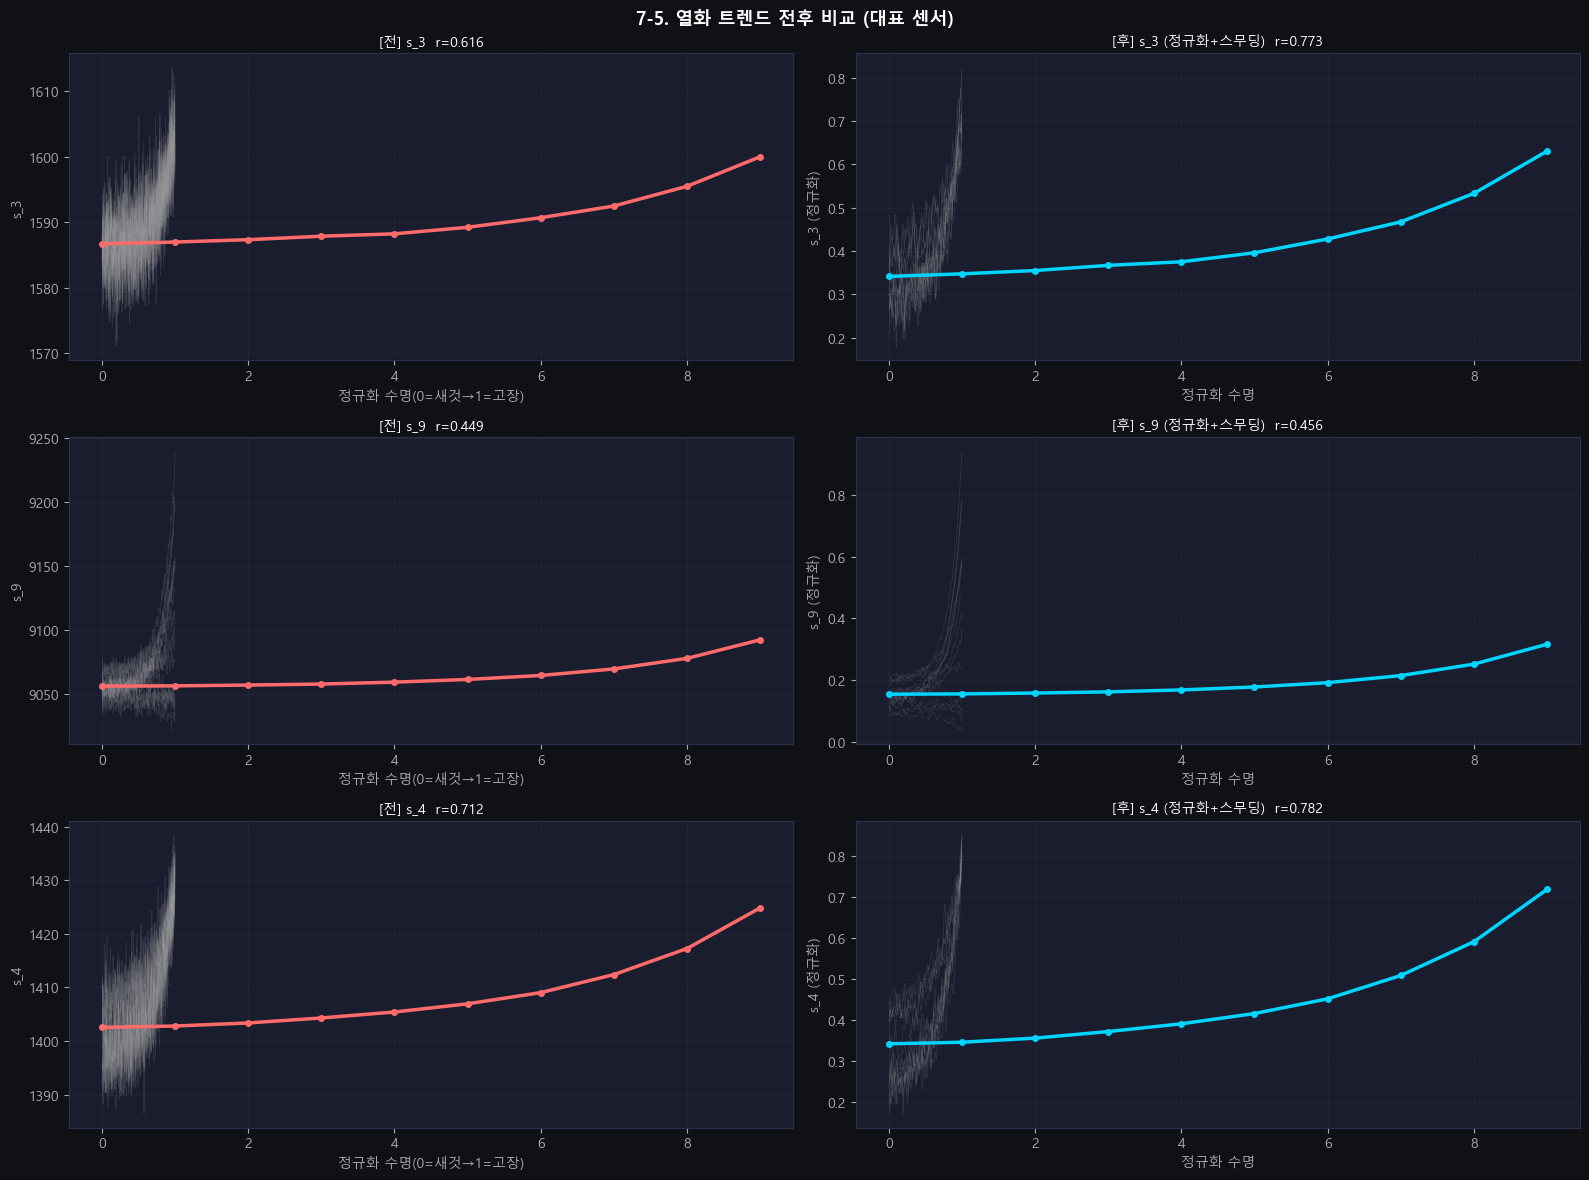

📌 전처리 후 트렌드가 더 매끄럽게 보임 = 노이즈 제거 효과
   트렌드 방향은 동일하게 유지 = 열화 신호 보존 확인


In [19]:
# 전처리 후 RUL 상관계수
rul_corr_after = train_s4[USEFUL_SENSORS+['RUL']].corr()['RUL'][USEFUL_SENSORS].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('7-5. RUL 상관계수 전처리 전(회색) vs 후(컬러)', fontsize=13, fontweight='bold')

# 전처리 후
bc = [C[1] if v<0 else C[2] for v in rul_corr_after]
bars = axes[0].barh(rul_corr_after.index, rul_corr_after.values, color=bc, alpha=0.85)
axes[0].axvline(0, color='white', lw=1, alpha=0.5)
axes[0].axvline( 0.3, color='yellow', lw=1.5, ls=':')
axes[0].axvline(-0.3, color='yellow', lw=1.5, ls=':')
axes[0].set_title('전처리 후 (14개 센서)')
axes[0].set_xlabel('Pearson r')
for bar, val in zip(bars, rul_corr_after.values):
    axes[0].text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

# 전후 변화 스캐터
common = [s for s in USEFUL_SENSORS if s in rul_corr_before.index]
r_b = rul_corr_before[common]
r_a = rul_corr_after[common]
axes[1].scatter(r_b, r_a, color=C[0], s=80, zorder=5)
for s in common:
    axes[1].annotate(s, (r_b[s], r_a[s]), fontsize=8, color=GRAY,
                     xytext=(4,4), textcoords='offset points')
lim = max(abs(r_b).max(), abs(r_a).max()) + 0.05
axes[1].plot([-lim,lim],[-lim,lim], color=GRAY, ls='--', lw=1, alpha=0.5, label='y=x (변화없음)')
axes[1].axhline(0, color=GRAY, lw=0.8, alpha=0.4)
axes[1].axvline(0, color=GRAY, lw=0.8, alpha=0.4)
axes[1].set_xlabel('전처리 전 r (RUL과의 상관)')
axes[1].set_ylabel('전처리 후 r (RUL과의 상관)')
axes[1].set_title('상관계수 변화 (y=x 선 위 = 상관 강화, 아래 = 약화)')
axes[1].legend()

plt.tight_layout(); plt.show()

# 열화 트렌드 전후 (대표 3개)
trend_s = [s for s in ['s_3','s_9','s_4'] if s in USEFUL_SENSORS]
if not trend_s: trend_s = USEFUL_SENSORS[:3]

tr_post = train_s4.copy()
mc = tr_post.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_post = tr_post.join(mc, on='unit_nr')
tr_post['norm_life'] = tr_post['time_cycles']/tr_post['max_c']

fig, axes = plt.subplots(len(trend_s), 2, figsize=(16, 4*len(trend_s)))
fig.suptitle('7-5. 열화 트렌드 전후 비교 (대표 센서)', fontsize=13, fontweight='bold')

for row, s in enumerate(trend_s):
    # 전처리 전
    ax = axes[row, 0]
    for u in tr_trend['unit_nr'].unique()[:15]:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    ax.plot(x_pos, trend_mean[s].values, color=C[1], lw=2.5, marker='o', markersize=4)
    r_val = corr_with_life.get(s, 0)
    ax.set_title(f'[전] {s}  r={r_val:.3f}', fontsize=10)
    ax.set_ylabel(s); ax.set_xlabel('정규화 수명(0=새것→1=고장)')

    # 전처리 후
    ax = axes[row, 1]
    post_trend = tr_post.groupby('life_bin' if 'life_bin' in tr_post.columns else 'unit_nr',
                                  observed=True)
    # 간단히 엔진별 샘플로 표시
    for u in tr_post['unit_nr'].unique()[:15]:
        sub = tr_post[tr_post['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    # 평균 트렌드
    tr_post['life_bin2'] = pd.cut(tr_post['norm_life'], bins=bins, labels=labels)
    pm = tr_post.groupby('life_bin2', observed=True)[s].mean()
    ax.plot(x_pos, pm.values, color=C[0], lw=2.5, marker='o', markersize=4)
    r_val_a = tr_post[['norm_life',s]].corr().iloc[0,1]
    ax.set_title(f'[후] {s} (정규화+스무딩)  r={r_val_a:.3f}', fontsize=10)
    ax.set_ylabel(s+' (정규화)'); ax.set_xlabel('정규화 수명')

plt.tight_layout(); plt.show()

print('📌 전처리 후 트렌드가 더 매끄럽게 보임 = 노이즈 제거 효과')
print('   트렌드 방향은 동일하게 유지 = 열화 신호 보존 확인')

---
## 8. CSV 저장 & 최종 요약

In [20]:
OUTPUT_DIR = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_path = os.path.join(OUTPUT_DIR, 'FD001_train_preprocessed.csv')
test_path  = os.path.join(OUTPUT_DIR, 'FD001_test_preprocessed.csv')
rul_path   = os.path.join(OUTPUT_DIR, 'FD001_test_RUL.csv')

train_s4.to_csv(train_path, index=False)
test_s4.to_csv( test_path,  index=False)
rul_df.to_csv(  rul_path,   index=False)

# 검증
chk_tr = pd.read_csv(train_path)
chk_te = pd.read_csv(test_path)
chk_rl = pd.read_csv(rul_path)

print('=' * 62)
print(' 전처리 파이프라인 완료 요약 (FD001)')
print('=' * 62)
print()

summary = pd.DataFrame({
    '항목': ['파일명','shape','센서 수','센서 범위','RUL 범위','결측치','파일 크기'],
    'Train': [
        'FD001_train_preprocessed.csv',
        str(chk_tr.shape),
        str(len(USEFUL_SENSORS)),
        f'{chk_tr[USEFUL_SENSORS].min().min():.4f} ~ {chk_tr[USEFUL_SENSORS].max().max():.4f}',
        f'{chk_tr["RUL"].min():.0f} ~ {chk_tr["RUL"].max():.0f}',
        str(chk_tr.isnull().sum().sum()),
        f'{os.path.getsize(train_path)/1024:.1f} KB',
    ],
    'Test': [
        'FD001_test_preprocessed.csv',
        str(chk_te.shape),
        str(len(USEFUL_SENSORS)),
        f'{chk_te[USEFUL_SENSORS].min().min():.4f} ~ {chk_te[USEFUL_SENSORS].max().max():.4f}',
        'RUL_FD001.txt 별도',
        str(chk_te.isnull().sum().sum()),
        f'{os.path.getsize(test_path)/1024:.1f} KB',
    ],
}).set_index('항목')
display(summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print(f'   ├─ FD001_train_preprocessed.csv  ({os.path.getsize(train_path)/1024:.1f} KB)')
print(f'   ├─ FD001_test_preprocessed.csv   ({os.path.getsize(test_path)/1024:.1f} KB)')
print(f'   └─ FD001_test_RUL.csv            ({os.path.getsize(rul_path)/1024:.1f} KB)')
print()
print('컬럼 구성 (Train):')
print(f'  {list(chk_tr.columns)}')
print()
print('다음 단계:')
print('  ML용  → 이 CSV에서 rolling 피처 추가 / test 엔진별 마지막 row')
print('  DL용  → window=30 슬라이딩으로 (N, 30, 14) 텐서 생성')

 전처리 파이프라인 완료 요약 (FD001)



,Train,Test
항목,,
파일명,FD001_train_preprocessed.csv,FD001_test_preprocessed.csv
shape,"(20631, 21)","(13096, 19)"
센서 수,14,14
센서 범위,0.0165 ~ 0.9750,0.0413 ~ 0.8827
RUL 범위,0 ~ 125,RUL_FD001.txt 별도
결측치,0,0
파일 크기,3691.8 KB,2255.6 KB



📄 저장 경로: c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\preprocessed/
   ├─ FD001_train_preprocessed.csv  (3691.8 KB)
   ├─ FD001_test_preprocessed.csv   (2255.6 KB)
   └─ FD001_test_RUL.csv            (0.4 KB)

컬럼 구성 (Train):
  ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'RUL_raw', 'RUL']

다음 단계:
  ML용  → 이 CSV에서 rolling 피처 추가 / test 엔진별 마지막 row
  DL용  → window=30 슬라이딩으로 (N, 30, 14) 텐서 생성


In [21]:
# 최종 Train 샘플
print('--- FD001_train_preprocessed.csv 샘플 (5행) ---')
display(chk_tr.head())
print()
print('--- FD001_test_preprocessed.csv 샘플 (5행) ---')
display(chk_te.head())

--- FD001_train_preprocessed.csv 샘플 (5행) ---


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,...,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL_raw,RUL
0,1,1,-0.0007,-0.0004,100.0,0.236640,0.395705,0.328167,0.706769,0.244956,...,0.338751,0.696186,0.227284,0.187139,0.359258,0.314652,0.681783,0.707882,191,125
1,1,2,0.0019,-0.0003,100.0,0.266257,0.378673,0.336281,0.702900,0.248503,...,0.312733,0.728178,0.236300,0.181563,0.349034,0.306962,0.662409,0.696126,190,125
2,1,3,-0.0043,0.0003,100.0,0.294198,0.355851,0.340788,0.703416,0.250072,...,0.282805,0.753230,0.242451,0.176906,0.335631,0.304079,0.644561,0.684251,189,125
3,1,4,0.0007,0.0000,100.0,0.314748,0.335665,0.338276,0.706623,0.245323,...,0.257377,0.763288,0.243785,0.173503,0.323621,0.306511,0.635197,0.674847,188,125
4,1,5,-0.0019,-0.0002,100.0,0.326479,0.326894,0.327916,0.708072,0.233026,...,0.242270,0.758857,0.240823,0.170638,0.315501,0.310425,0.637692,0.668570,187,125



--- FD001_test_preprocessed.csv 샘플 (5행) ---


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,0.0023,0.0003,100.0,0.436757,0.325303,0.278008,0.686531,0.203255,0.132606,0.266692,0.667350,0.231023,0.150993,0.307171,0.348035,0.610755,0.674643
1,1,2,-0.0027,-0.0003,100.0,0.395404,0.326191,0.289924,0.695978,0.199488,0.132667,0.286983,0.673220,0.235432,0.157418,0.311050,0.343163,0.633945,0.680017
2,1,3,0.0003,0.0001,100.0,0.365413,0.320165,0.304222,0.698836,0.195659,0.130614,0.296036,0.676833,0.239959,0.160881,0.315838,0.328046,0.649307,0.682791
3,1,4,0.0042,0.0000,100.0,0.347262,0.307404,0.316002,0.695277,0.192586,0.127543,0.291938,0.680499,0.245115,0.161167,0.319856,0.308019,0.652448,0.681520
4,1,5,0.0014,0.0000,100.0,0.334533,0.292733,0.323651,0.688402,0.192225,0.125605,0.280023,0.686657,0.251059,0.159910,0.323442,0.293010,0.646965,0.677123
